In [ ]:
# @title Install required libraries (try-catch safe)
"""
NOTE: You can save the Docker image state after running this block so that you don't have to run it every time you start a new environment.
"""
import os, re

def replace_in_file(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        content = file.read()

    # Replace 'ufl' with 'ufl_legacy'
    content = re.sub(r'\bufl\b', 'ufl_legacy', content)

    with open(file_path, 'w', encoding='utf-8') as file:
        file.write(content)

def process_directory(directory):
    for root, _, files in os.walk(directory):
        for file in files:
            if file.endswith('.py'):
                file_path = os.path.join(root, file)
                replace_in_file(file_path)

# ipywidgets
try:
    import ipywidgets
except ImportError:
    !pip install ipywidgets

# dolfin
try:
    import dolfin
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
    import dolfin

# block
try:
    import block
except ImportError:
    !git clone "https://bitbucket.org/fenics-apps/cbc.block/src/master/"
    !pip install master/

# fenics_ii
try:
    import xii
except ImportError:
    !git clone "https://github.com/MiroK/fenics_ii"
    process_directory("fenics_ii/")
    !pip install fenics_ii/

# vtk
try:
    import vtk
except ImportError:
    !pip install vtk

# graphnics
try:
    import graphnics
except ImportError:
    !git clone "https://github.com/IngeborgGjerde/graphnics"
    !pip install graphnics/

# meshio
try:
    import meshio
except ImportError:
    !pip install meshio

# pyvista
try:
    import pyvista
except ImportError:
    !pip install pyvista

--2026-07-07 13:57:29--  https://fem-on-colab.github.io/releases/fenics-install-release-real.sh
Resolving fem-on-colab.github.io (fem-on-colab.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to fem-on-colab.github.io (fem-on-colab.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4180 (4.1K) [application/x-sh]
Saving to: ‘/tmp/fenics-install.sh’

/tmp/fenics-install 100%[===================>]   4.08K  --.-KB/s    in 0s      

2026-07-07 13:57:29 (47.5 MB/s) - ‘/tmp/fenics-install.sh’ saved [4180/4180]

+ INSTALL_PREFIX=/usr/local
++ echo /usr/local
++ awk -F/ '{print NF-1}'
+ INSTALL_PREFIX_DEPTH=2
+ PROJECT_NAME=fem-on-colab
+ SHARE_PREFIX=/usr/local/share/fem-on-colab
+ FENICS_INSTALLED=/usr/local/share/fem-on-colab/fenics.installed
+ [[ ! -f /usr/local/share/fem-on-colab/fenics.installed ]]
+ PYBIND11_INSTALL_SCRIPT_PATH=https://github.com/fem-on-colab/fem-on-colab.github.io/raw/e12a85f2/releases/pybi

In [ ]:
#@title Define functions

import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import dolfin as df
from graphnics import *
from math import gamma
from argparse import RawDescriptionHelpFormatter
from petsc4py import PETSc
from xii import *
import time
import networkx as nx
from scipy.spatial import cKDTree
from itertools import combinations
from collections import deque

import os
import vtk

def get_fg_from_vtk_bifs(filename: str, *, radius_field="Radius", tol=1e-6) -> FenicsGraph:
    # --- read polydata ---
    fname = filename.lower()
    reader = vtk.vtkXMLPolyDataReader() if fname.endswith(".vtp") else vtk.vtkPolyDataReader()
    reader.SetFileName(filename)
    reader.Update()
    poly = reader.GetOutput()

    pts = poly.GetPoints()
    n_points = pts.GetNumberOfPoints()
    X = np.array([pts.GetPoint(i) for i in range(n_points)], dtype=float)

    # --- radii on points (fallback = 1) ---
    radii = np.ones(n_points, dtype=float)
    pd = poly.GetPointData()
    if pd is not None:
        arr = pd.GetArray(radius_field)
        if arr is None:
            for j in range(pd.GetNumberOfArrays()):
                name_j = pd.GetArrayName(j)
                if name_j and "radius" in name_j.lower():
                    arr = pd.GetArray(j)
                    radius_field = name_j
                    break
        if arr is not None:
            radii = np.array([arr.GetTuple1(i) for i in range(n_points)], dtype=float)

    # --- merge points within tol using KDTree ---
    kdt = cKDTree(X)
    visited = np.zeros(n_points, dtype=bool)
    rep = np.full(n_points, -1, dtype=int)   # map old id -> representative id

    reps = []
    for i in range(n_points):
        if visited[i]:
            continue
        nbrs = kdt.query_ball_point(X[i], r=tol)
        for j in nbrs:
            visited[j] = True
            rep[j] = i
        reps.append(i)

    # compress representative ids to 0..n_unique-1
    rep_to_new = {rid: k for k, rid in enumerate(reps)}
    old_to_new = np.array([rep_to_new[rep[i]] for i in range(n_points)], dtype=int)

    # --- build graph nodes on unique reps ---
    G = FenicsGraph()
    for rid in reps:
        nid = rep_to_new[rid]
        G.add_node(nid, pos=X[rid].tolist(), radius=float(radii[rid]))

    # --- add edges from polyline connectivity, using merged ids ---
    lines = poly.GetLines()
    id_list = vtk.vtkIdList()
    lines.InitTraversal()

    while lines.GetNextCell(id_list):
        n_ids = id_list.GetNumberOfIds()
        if n_ids < 2:
            continue
        prev = old_to_new[int(id_list.GetId(0))]
        for k in range(1, n_ids):
            curr = old_to_new[int(id_list.GetId(k))]
            if prev != curr and not G.has_edge(prev, curr):
                G.add_edge(prev, curr)
                # edge radius: average of node radii (or compute better if you want)
                G.edges[prev, curr]["radius"] = 0.5*(G.nodes[prev]["radius"] + G.nodes[curr]["radius"])
            prev = curr

    # --- optional: pre-tag junctions/endpoints for debugging ---
    for n in G.nodes:
        deg = G.degree[n]
        G.nodes[n]["is_junction"] = int(deg > 2)
        G.nodes[n]["is_terminal"] = int(deg == 1)

    return G


#pv_frames_dir="frame_fenicsGraph_block0123_new"
#os.makedirs(pv_frames_dir)  # create a fresh, empty folder

def load_patient_vtp(vtp_path):
    """
    Load pt002_inflow_centerline.vtp into a FenicsGraph.
    The raw network has 32 cycles; a maximum-spanning-tree is extracted,
    weighted by pressure gradient for real edges vs near-zero for phantom edges.
    Returns (FenicsGraph tree, root) where root is the inlet vertex (highest pressure).
    """
    reader = vtk.vtkXMLPolyDataReader()
    reader.SetFileName(vtp_path)
    reader.Update()
    poly = reader.GetOutput()

    n_pts = poly.GetNumberOfPoints()
    pts   = np.array([poly.GetPoint(i) for i in range(n_pts)])

    pd       = poly.GetPointData()
    pressure = np.array([pd.GetArray('pressure_mmhg').GetValue(i) for i in range(n_pts)])
    radius_p = np.array([pd.GetArray('radius_mm').GetValue(i)     for i in range(n_pts)])

    cd             = poly.GetCellData()
    is_phantom_arr = cd.GetArray('is_phantom')

    G_nx = nx.Graph()
    for i in range(n_pts):
        G_nx.add_node(i, pos=pts[i].tolist(),
                      radius=float(radius_p[i]),
                      pressure=float(pressure[i]))

    lines   = poly.GetLines()
    id_list = vtk.vtkIdList()
    lines.InitTraversal()
    cell_idx = 0
    while lines.GetNextCell(id_list):
        n_ids   = id_list.GetNumberOfIds()
        phantom = bool(is_phantom_arr.GetValue(cell_idx)) if is_phantom_arr else False
        prev    = int(id_list.GetId(0))
        for k in range(1, n_ids):
            curr   = int(id_list.GetId(k))
            length = float(np.linalg.norm(pts[curr] - pts[prev]))
            dp     = abs(float(pressure[curr]) - float(pressure[prev]))
            weight = (dp / (length + 1e-10)) if not phantom else 1e-6
            if not G_nx.has_edge(prev, curr):
                G_nx.add_edge(prev, curr, is_phantom=phantom, length=length, weight=weight)
            prev = curr
        cell_idx += 1

    n_comp = nx.number_connected_components(G_nx)
    print(f"Raw graph: {G_nx.number_of_nodes()} nodes, {G_nx.number_of_edges()} edges, "
          f"{n_comp} component(s)")

    T = nx.maximum_spanning_tree(G_nx, weight='weight')
    phantom_kept = sum(1 for u,v,d in T.edges(data=True) if d.get('is_phantom', False))
    print(f"Spanning tree: {T.number_of_nodes()} nodes, {T.number_of_edges()} edges "
          f"({phantom_kept} phantom edges retained for connectivity)")

    inlet = int(np.argmax(pressure))
    print(f"Inlet vertex: {inlet},  p = {pressure[inlet]:.1f} mmHg,  "
          f"pos = {[round(x,2) for x in pts[inlet].tolist()]}")

    # FenicsGraph is a DiGraph: every edge must point away from the root (parent -> child),
    # otherwise downstream BFS/tangent/mesh logic only sees a few directly-oriented edges.
    # nx.maximum_spanning_tree returns an undirected tree with arbitrary edge orientation,
    # so re-orient via BFS from the inlet before building FG.
    T_dir = nx.bfs_tree(T, source=inlet)
    n_reachable = T_dir.number_of_nodes()
    if n_reachable != T.number_of_nodes():
        print(f"WARNING: only {n_reachable}/{T.number_of_nodes()} nodes reachable from inlet in spanning tree")

    FG = FenicsGraph()
    for n, d in sorted(T.nodes(data=True)):
        FG.add_node(n, pos=d['pos'], radius=d['radius'])
    for u, v in T_dir.edges():
        edata = T.edges[u, v]
        r = 0.5 * (G_nx.nodes[u]['radius'] + G_nx.nodes[v]['radius'])
        FG.add_edge(u, v, radius=r, is_phantom=edata.get('is_phantom', False))

    return FG, inlet


# === Load patient centerline ===
VTP_PATH = "pt002_inflow_centerline.vtp"
G, root  = load_patient_vtp(VTP_PATH)

junctions = [n for n in G.nodes if G.degree[n] > 2]
terminals = [n for n in G.nodes if G.degree[n] == 1]
print(f"#nodes: {len(G.nodes)}  #edges: {len(G.edges)}")
print(f"#junctions: {len(junctions)}  #terminals: {len(terminals)}")

def assign_vessel_ids_by_junction_terminal_paths(G, min_edge_length=1e-6):
    """
    Vessel = maximal path between important nodes:
      important = terminals (deg=1) and junctions (deg>=3)

    Also ignores ultra-short edges (from duplicated points / merge artifacts).
    """
    pos = nx.get_node_attributes(G, "pos")

    def elen(u, v):
        pu = np.array(pos[u], float); pv = np.array(pos[v], float)
        return float(np.linalg.norm(pu - pv))

    important = {n for n in G.nodes if (G.degree[n] == 1 or G.degree[n] >= 3)}

    used = set()
    vessel_id = 0

    def ekey(u, v):  # undirected key
        return (u, v) if u <= v else (v, u)

    for s in important:
        for nb in G.neighbors(s):
            if elen(s, nb) < min_edge_length:
                continue

            e0 = ekey(s, nb)
            if e0 in used:
                continue

            # walk from s -> nb until next important node
            path = [s, nb]
            prev, cur = s, nb
            used.add(e0)

            while cur not in important:
                nbs = [x for x in G.neighbors(cur) if elen(cur, x) >= min_edge_length]
                if len(nbs) == 0:
                    break
                if len(nbs) == 1:
                    nxt = nbs[0]
                else:
                    # choose neighbor that's not prev; if multiple, pick the one with smallest turning angle (straightest)
                    candidates = [x for x in nbs if x != prev]
                    if not candidates:
                        break
                    # pick the "straightest" continuation
                    pc = np.array(pos[cur], float)
                    pprev = np.array(pos[prev], float)
                    v_in = pc - pprev
                    v_in /= (np.linalg.norm(v_in) + 1e-16)

                    best = None
                    best_dot = -1e9
                    for x in candidates:
                        px = np.array(pos[x], float)
                        v_out = px - pc
                        v_out /= (np.linalg.norm(v_out) + 1e-16)
                        d = float(np.dot(v_in, v_out))
                        if d > best_dot:
                            best_dot = d
                            best = x
                    nxt = best

                e = ekey(cur, nxt)
                if e in used:
                    break

                used.add(e)
                path.append(nxt)
                prev, cur = cur, nxt

            # label all edges in this path with vessel_id
            for i in range(len(path) - 1):
                u, v = path[i], path[i+1]
                G.edges[u, v]["vessel_id"] = vessel_id

            vessel_id += 1

    return vessel_id





nv = assign_vessel_ids_by_junction_terminal_paths(G, min_edge_length=1e-5)

# Some real centerlines (pt002) contain near-duplicate / zero-length point pairs
# that fall below min_edge_length and get skipped by the chain walk above, leaving
# their edge without a vessel_id. Backfill those as singleton vessels so downstream
# radius lookup (build_radius_map_constant_per_vessel) never KeyErrors/RuntimeErrors.
_missing = [(u, v) for u, v in G.edges() if "vessel_id" not in G.edges[u, v]]
if _missing:
    print(f"Assigning fallback vessel_id to {len(_missing)} short/duplicate-point edge(s)")
    for u, v in _missing:
        G.edges[u, v]["vessel_id"] = nv
        nv += 1
print(f"Total vessels: {nv}")

def bif_tangents(G):
    pos   = nx.get_node_attributes(G,"pos")
    nodes = list(G.nodes)
    T     = np.zeros((len(nodes),3))
    for k, n in enumerate(nodes):
        p0 = np.array(pos[n])
        neighbor = list(G.neighbors(n))
        vec = np.zeros(3)
        for m in neighbor:
            vec += np.array(pos[m]) - p0

        norm = np.linalg.norm(vec)
        if norm > 0:
          T[k,:] = vec/norm
        else:
          T[k,:] = np.array([0,0,1.0]) #use unit normal if needed
    P = np.array([pos[n] for n in nodes])
    return nodes, P, T

class TangentExpression(UserExpression):
    def __init__(self, nodes, P, T_array, **kwargs):
        self.nodes  = nodes
        self.P      = np.asarray(P)
        self.T_array = np.asarray(T_array)
        self.kdtree = cKDTree(self.P)
        super().__init__(**kwargs)
    def eval(self,values,x):
      _, idx = self.kdtree.query((x[0],x[1],x[2]))
      tx, ty, tz = self.T_array[idx]
      values[0] = tx
      values[1] = ty
      values[2] = tz
    def value_shape(self):
      return (3,)

def build_bifurcation_pairs_bifs(G, root, *, require_tree_like=True):
    """
    General parent/daughter classification at junctions using graph-distance from a chosen inlet/root.

    Parameters
    ----------
    G : networkx.Graph-like
        Works with FenicsGraph or nx.Graph. Must support neighbors(), degree, nodes data with "pos".
    root : int
        Upstream inlet node id in G.
    require_tree_like : bool
        If True, enforce that each junction has exactly one upstream neighbor.
        If False, allow ambiguous cases and pick parent by smallest distance.

    Returns
    -------
    results : list[dict]
        Each dict has:
          - bif_node
          - parent (graph node id)
          - daughters (list of graph node ids)
          - parent_id (always 1)
          - daughter_id (2..)
          - pairs: [(1,2),(1,3),(2,3)] etc.
          - pos: np.array([x,y,z])
          - neighbor_sorted: [parent] + daughters
          - vessel_id: {parent:1, daughter1:2, ...}
          - dist_b: distance(root -> bif_node)
          - dist_neighbors: {nb: dist(root -> nb)}
    """

    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))
    H.add_edges_from(G.edges())

    pos  = nx.get_node_attributes(H, "pos")
    dist = dict(nx.single_source_shortest_path_length(H, source=root))

    bif_nodes = [n for n in H.nodes if H.degree[n] > 2]
    results = []

    for b in bif_nodes:
        nbrs = list(H.neighbors(b))
        db = dist.get(b, None)
        if db is None:
            if require_tree_like:
                raise RuntimeError(f"Junction {b} not reachable from root={root}.")
            continue

        # STRICT tree rule: parent is db-1, daughters are db+1
        upstream   = [n for n in nbrs if dist.get(n, None) == db - 1]
        downstream = [n for n in nbrs if dist.get(n, None) == db + 1]

        if require_tree_like and len(upstream) != 1:
            raise RuntimeError(
                f"Junction {b} ambiguous: dist[b]={db}, "
                f"upstream={upstream}, downstream={downstream}, neighbors={nbrs}"
            )

        parent = upstream[0] if len(upstream) else min(nbrs, key=lambda n: dist.get(n, 10**18))
        daughters = sorted([n for n in nbrs if n != parent],
                           key=lambda n: (dist.get(n, 10**18), int(n)))

        vessel_id = {parent: 1}
        for k, d in enumerate(daughters, start=2):
            vessel_id[d] = k

        daughter_id = [vessel_id[d] for d in daughters]
        pairs = [(1, did) for did in daughter_id] + list(combinations(daughter_id, 2))

        results.append({
            "bif_node": b,
            "parent": parent,
            "daughters": daughters,
            "pairs": pairs,
            "pos": np.array(pos[b], dtype=float),
            "neighbor_sorted": [parent] + daughters,
            "dist_b": db,
            "dist_neighbors": {n: dist.get(n, None) for n in nbrs},
        })

    results.sort(key=lambda r: (r["dist_b"], int(r["bif_node"])))
    return results

# root is returned by load_patient_vtp above (vertex 335 for pt002, p=882 mmHg)
# bif_info is computed inside the simulation cell below



def bifurcation_vertices_from_graph(Lambda, bif_info):
    """Return mesh vertex indices of bifurcation points (nearest vertex to each bif node position)."""
    coords = Lambda.coordinates()

    def nearest_vertex(point):
        diff = coords - point
        return int(np.argmin(np.linalg.norm(diff, axis=1)))

    bif_vertices = []
    for bif in bif_info:
        vtx = nearest_vertex(bif["pos"])
        bif_vertices.append(vtx)
    return sorted(set(bif_vertices))


def add_kirchhoff_junction_terms_P1DG(
    A_petsc, V3, V1, Lambda, bif_vertices, D_area_expr,
    eta_gamma=10.0, epsilon=1.0
):
    """
    Assemble Kirchhoff/SIPG junction terms by writing directly into the PETSc Mat.

    """
    dm = V1.dofmap()
    coords = Lambda.coordinates()

    Lambda.init(0, 1)
    v2c = Lambda.topology()(0, 1)

    N = A_petsc.mat().getSize()[0]
    off1 = N - V1.dim()   # assumes V1 block is last in ii_convert ordering

    # get petsc4py Mat
    M = A_petsc.mat()

    M.setOption(PETSc.Mat.Option.NEW_NONZERO_ALLOCATION_ERR, False)
    M.setOption(PETSc.Mat.Option.NEW_NONZERO_LOCATION_ERR, False)

    def add_entry(I, J, val):
        # addv=True means accumulate into existing entry
        M.setValue(I, J, val, addv=True)

    for vtx in bif_vertices:
        incident_cells = list(v2c(vtx))
        m = len(incident_cells)
        if m < 3:
            continue

        branches = []
        h_gamma = 0.0

        for c in incident_cells:
            cell = Cell(Lambda, c)
            vids = cell.entities(0)
            x0 = coords[vids[0]]
            x1 = coords[vids[1]]
            hK = float(np.linalg.norm(x1 - x0))
            h_gamma = max(h_gamma, hK)

            if vids[0] == vtx:
                loc_g, loc_o = 0, 1
                x_mid = 0.5*(x0 + x1)
            else:
                loc_g, loc_o = 1, 0
                x_mid = 0.5*(x0 + x1)

            cdofs = dm.cell_dofs(c)  # DG1: 2 dofs per cell
            dof_g = int(cdofs[loc_g])
            dof_o = int(cdofs[loc_o])

            Da = float(D_area_expr(Point(*x_mid)))
            branches.append(dict(hK=hK, Da=Da, dof_g=dof_g, dof_o=dof_o))

        for a in range(m):
            for b in range(a + 1, m):
                Ia = branches[a]
                Ib = branches[b]

                ha, Da = Ia["hK"], Ia["Da"]
                hb, Db = Ib["hK"], Ib["Da"]
                ga, oa = Ia["dof_g"], Ia["dof_o"]
                gb, ob = Ib["dof_g"], Ib["dof_o"]

                # GLOBAL indices
                Gga, Goa = off1 + ga, off1 + oa
                Ggb, Gob = off1 + gb, off1 + ob

                # === penalty ===
                pen = eta_gamma / h_gamma
                for (I, sI) in [(Gga, +1.0), (Ggb, -1.0)]:
                    for (J, sJ) in [(Gga, +1.0), (Ggb, -1.0)]:
                        add_entry(I, J, pen * sI * sJ)

                # === Consistency: restored — a11 now uses full SIPG (matching a00) ===
                # Old reason for disabling: "interior a11 uses penalty-only" — no longer applies.
                # a00 always had full SIPG; a11 was made penalty-only incorrectly.
                # Kept old commented block below for reference:
                # # w = +1.0 / m  [OLD — when a11 was penalty-only]
                # # for (Row, srow) in [(Gga, +1.0), (Ggb, -1.0)]:
                # #     add_entry(Row, Goa, w * srow * ( Da/ha))
                # #     add_entry(Row, Gga, w * srow * (-Da/ha))
                # #     add_entry(Row, Gob, w * srow * (-Db/hb))
                # #     add_entry(Row, Ggb, w * srow * ( Db/hb))
                # FIX7: sign corrected (reference notebook + 500-step validation).
                # Old wrong-sign active line kept below for reference:
                # w = +1.0 / m
                w = -1.0 / m
                for (Row, srow) in [(Gga, +1.0), (Ggb, -1.0)]:
                    add_entry(Row, Goa, w * srow * ( Da/ha))
                    add_entry(Row, Gga, w * srow * (-Da/ha))
                    add_entry(Row, Gob, w * srow * (-Db/hb))
                    add_entry(Row, Ggb, w * srow * ( Db/hb))

                # === Adjoint consistency: restored ===
                # # ws = +epsilon / m  [OLD — when a11 was penalty-only]
                # # for (Col, scol) in [(Gga, +1.0), (Ggb, -1.0)]:
                # #     add_entry(Goa, Col, ws * scol * ( Da/ha))
                # #     add_entry(Gga, Col, ws * scol * (-Da/ha))
                # #     add_entry(Gob, Col, ws * scol * (-Db/hb))
                # #     add_entry(Ggb, Col, ws * scol * ( Db/hb))
                # FIX7: adjoint sign corrected.
                # ws = +epsilon / m  [OLD WRONG]
                ws = -epsilon / m
                for (Col, scol) in [(Gga, +1.0), (Ggb, -1.0)]:
                    add_entry(Goa, Col, ws * scol * ( Da/ha))
                    add_entry(Gga, Col, ws * scol * (-Da/ha))
                    add_entry(Gob, Col, ws * scol * (-Db/hb))
                    add_entry(Ggb, Col, ws * scol * ( Db/hb))

    # finalize PETSc assembly
    M.assemblyBegin()
    M.assemblyEnd()

def advection_junction_terms_P1DG(
    A_petsc, V3, V1, Lambda, bif_vertices, D_area_expr, dist,
    q1_value=1.0
):
    dm = V1.dofmap()
    coords = Lambda.coordinates()

    Lambda.init(0, 1)
    v2c = Lambda.topology()(0, 1)

    # Use the same safe offset as for diffusion:
    N = A_petsc.mat().getSize()[0]
    off1 = N - V1.dim()   # V1 block last

    M = A_petsc.mat()
    M.setOption(PETSc.Mat.Option.NEW_NONZERO_ALLOCATION_ERR, False)
    M.setOption(PETSc.Mat.Option.NEW_NONZERO_LOCATION_ERR, False)

    def add_entry(I, J, val):
        M.setValue(I, J, float(val), addv=True)

    for vtx in bif_vertices:
        cells = list(v2c(vtx))
        if len(cells) < 3:
            continue

        dv = dist.get(int(vtx),None)
        if dv is None:
            continue

        branches = []

        # 1) collect branch data
        for c in cells:
            cell = Cell(Lambda, c)
            vids = list(map(int,cell.entities(0)))
            x0, x1 = coords[vids[0]], coords[vids[1]]

            if vids[0] == int(vtx):
                loc_g = 0
                v_other = vids[1]
                x_mid = 0.5*(x0 + x1)
            else:
                loc_g = 1
                v_other = vids[0]
                x_mid = 0.5*(x0 + x1)

            dof_g = int(dm.cell_dofs(c)[loc_g])
            A_here = float(D_area_expr(Point(*x_mid)))
            Q_here = A_here * float(q1_value)
            d_other = dist.get(int(v_other),None)

            branches.append({
                "dof_g": dof_g,
                "Q": Q_here,
                "d_other": d_other,
                "v_other": v_other
            })

        # 2) parent: other vertex is closer to inlet than a junction
        upstream = [b for b in branches if b["d_other"] is not None and b["d_other"] < dv]
        downstream = [b for b in branches if b["d_other"] is not None and b["d_other"]>dv]

        if len(upstream) !=1:
          continue

        inflow = upstream[0]
        outflows = downstream
        if len(outflows) == 0:
            continue

        Gin = off1 + inflow["dof_g"]

        # 3) assemble: sum_out Q_out * u_in * (v_out - v_in)
        Qsum = 0.0
        for b in outflows:
            Gout = off1 + b["dof_g"]
            Q = b["Q"]
            Qsum += Q
            add_entry(Gout, Gin, +Q)   # v_out * u_in
        add_entry(Gin, Gin, -Qsum)     # -v_in * u_in

    M.assemblyBegin()
    M.assemblyEnd()


def kirchhoff_residual_at_vertex(Lambda, V1, uh1d, vtx, D_area_expr):
  coords = Lambda.coordinates()
  dm = V1.dofmap()

  Lambda.init(0, 1)
  v2c = Lambda.topology()(0, 1)
  cells = list(v2c(vtx))

  res = 0.0
  fluxes = []
  for c in cells:
      cell = Cell(Lambda, c)
      vids = cell.entities(0)
      x0 = coords[vids[0]]
      x1 = coords[vids[1]]
      hK = float(np.linalg.norm(x1 - x0))
      x_mid = 0.5*(x0 + x1)
      Da = float(D_area_expr(Point(*x_mid)))

      cdofs = dm.cell_dofs(c)
      # local dof at junction vs other endpoint
      if vids[0] == vtx:
          dof_g, dof_o = int(cdofs[0]), int(cdofs[1])
      else:
          dof_g, dof_o = int(cdofs[1]), int(cdofs[0])

      ug = uh1d.vector()[dof_g]
      uo = uh1d.vector()[dof_o]
      F = Da * (uo - ug) / hK  # outgoing flux from junction into cell
      fluxes.append(F)
      res += F

  return res, fluxes

def advection_junction_terms_P1DG_flow_based(
    A_petsc, V1, Lambda, bif_vertices, D_area_expr, t_vec, velocity_expr
):
    dm = V1.dofmap()
    coords = Lambda.coordinates()
    Lambda.init(0, 1)
    v2c = Lambda.topology()(0, 1)

    N = A_petsc.mat().getSize()[0]
    off1 = N - V1.dim()

    M = A_petsc.mat()
    M.setOption(PETSc.Mat.Option.NEW_NONZERO_ALLOCATION_ERR, False)
    M.setOption(PETSc.Mat.Option.NEW_NONZERO_LOCATION_ERR, False)

    def add_entry(I, J, val):
        M.setValue(I, J, float(val), addv=True)

    # Direct DG0 dof-vector access — Point-eval is unreliable for DG0 Functions
    # on 1D meshes embedded in 3D space (FEniCS bounding-box collision returns 0).
    _vel_arr = velocity_expr.vector().get_local()
    _dm_vel  = velocity_expr.function_space().dofmap()
    _n_proc  = 0
    _n_skip  = 0

    for vtx in bif_vertices:
        cells = list(v2c(vtx))
        if len(cells) < 3:
            continue

        xg = coords[vtx]
        branches = []

        for c in cells:
            cell = Cell(Lambda, c)
            vids = cell.entities(0)
            x0, x1 = coords[vids[0]], coords[vids[1]]

            # vector from junction -> other endpoint (points into the branch)
            if vids[0] == vtx:
                loc_g = 0
                xother = x1
            else:
                loc_g = 1
                xother = x0

            d = xother - xg
            d_hat = d / np.linalg.norm(d)

            x_mid = 0.5*(xg + xother)
            tmid  = np.array(t_vec(Point(*x_mid)))
            _tn   = np.linalg.norm(tmid)
            if _tn < 1e-14:
                continue
            tmid /= _tn

            # signed velocity along this branch away from junction
            # Direct DG0 cell-dof lookup (reliable on 1D mesh in 3D):
            v_mag = float(_vel_arr[int(_dm_vel.cell_dofs(c)[0])])
            s = v_mag * float(np.dot(tmid, d_hat))

            A = float(D_area_expr(Point(*x_mid)))
            Q = A * abs(s)

            dof_g = int(dm.cell_dofs(c)[loc_g])

            branches.append(dict(cell=c, dof_g=dof_g, s=s, Q=Q))

        inflows  = [b for b in branches if b["s"] < 0.0 and b["Q"] > 0.0]
        outflows = [b for b in branches if b["s"] > 0.0 and b["Q"] > 0.0]

        #print(f"Junction {vtx}: inflows={len(inflows)}, outflows={len(outflows)}, "
        #      f"s={[round(b['s'],4) for b in branches]}, "
        #      f"Q={[round(b['Q'],6) for b in branches]}")

        if len(outflows) == 0 or len(inflows) == 0:
            _n_skip += 1
            continue
        _n_proc += 1

        # Correct upwind at junction (Kuchta-Masri-Riviere sign convention):
        #   Gin (inflow junction dof) loses drug via junction outflow  -> +diagonal on Gin
        #   Gout (outflow junction dof) gains drug from Gin            -> -off-diagonal Gout<-Gin
        Q_in_sum = sum(b["Q"] for b in inflows)

        # FIX7: sign/structure corrected per reference notebook + 500-step validation.
        # Reference puts negative diagonal on OUTFLOW Gout (not inflow Gin) and
        # the off-diagonal Gout<-Gin coupling is POSITIVE. Old wrong-sign block:
        # for bin_ in inflows:
        #     Gin = off1 + bin_["dof_g"]
        #     add_entry(Gin, Gin, +bin_["Q"])   # OLD WRONG
        # for bout in outflows:
        #     Gout = off1 + bout["dof_g"]
        #     Qout = bout["Q"]
        #     for bin_ in inflows:
        #         Gin  = off1 + bin_["dof_g"]
        #         add_entry(Gout, Gin, -Qout * (bin_["Q"] / Q_in_sum))  # OLD WRONG
        for bout in outflows:
            Gout = off1 + bout["dof_g"]
            Qout = bout["Q"]
            for bin_ in inflows:
                Gin = off1 + bin_["dof_g"]
                add_entry(Gout, Gin, Qout * (bin_["Q"] / Q_in_sum))
            add_entry(Gout, Gout, -Qout)

    print(f"[junc-adv] processed={_n_proc}, skipped={_n_skip} "
          f"(skipped means no clear inflow or all Q=0)")
    M.assemblyBegin()
    M.assemblyEnd()


def build_cell_tangent_expression(Lambda, degree=0):
    coords = Lambda.coordinates()
    conn   = Lambda.cells()

    # === BFS distances on vertex graph ===
    adj = {v: [] for v in range(Lambda.num_vertices())}
    for a, b in conn:
        a = int(a); b = int(b)
        adj[a].append(b); adj[b].append(a)

    dist = {int(inlet_v):0}
    q = deque([int(inlet_v)])
    while q:
        v = q.popleft()
        for nb in adj[v]:
            if nb not in dist:
                dist[nb] = dist[v] + 1
                q.append(nb)

    # === downstream tangent (smaller to larger) ===
    cell_mids = []
    cell_tans = []

    for (a, b) in conn:
        a = int(a); b = int(b)

        da = dist.get(a, None)
        db = dist.get(b, None)

        if da is None or db is None:
            up, dn = a, b
        else:
            up, dn = (a, b) if da <= db else (b, a)

        x_up = coords[up]
        x_dn = coords[dn]

        t = x_dn - x_up
        nrm = np.linalg.norm(t)
        if nrm < 1e-14:
            t = np.array([1.0, 0.0, 0.0])
        else:
            t = t / nrm

        cell_mids.append(0.5*(x_up + x_dn))
        cell_tans.append(t)

    cell_mids = np.array(cell_mids)
    cell_tans = np.array(cell_tans)
    kdt = cKDTree(cell_mids)

    class CellTangent(UserExpression):
        def eval(self, values, x):
            _, idx = kdt.query((x[0], x[1], x[2]))
            values[:] = cell_tans[idx]
        def value_shape(self): return (3,)

    return CellTangent(degree=degree), dist

def build_bfs_tangent_expression(Lambda, inlet_v, degree=0,return_dist=False):
    coords = Lambda.coordinates()
    conn   = Lambda.cells()  # (v0,v1) per cell

    # === BFS distances on the vertex graph ===
    adj = {v: [] for v in range(Lambda.num_vertices())}
    for a, b in conn:
        a = int(a); b = int(b)
        adj[a].append(b); adj[b].append(a)

    dist = {int(inlet_v): 0}
    q = deque([int(inlet_v)])
    while q:
        v = q.popleft()
        for nb in adj[v]:
            if nb not in dist:
                dist[nb] = dist[v] + 1
                q.append(nb)

    # === per-cell downstream tangent (from smaller dist -> larger dist) ===
    cell_mids = []
    cell_tans = []

    for c, (a, b) in enumerate(conn):
        a = int(a); b = int(b)
        da = dist.get(a, None)
        db = dist.get(b, None)
        if da is None or db is None:

            up, dn = a, b
        else:
            up, dn = (a, b) if da <= db else (b, a)

        x_up = coords[up]
        x_dn = coords[dn]
        t = x_dn - x_up
        t /= np.linalg.norm(t)

        cell_mids.append(0.5*(x_up + x_dn))
        cell_tans.append(t)

    cell_mids = np.array(cell_mids)
    cell_tans = np.array(cell_tans)
    kdt = cKDTree(cell_mids)

    class BFSTangent(UserExpression):
        def eval(self, values, x):
            _, idx = kdt.query((x[0], x[1], x[2]))
            values[:] = cell_tans[idx]
        def value_shape(self):
            return (3,)

    expr = BFSTangent(degree=degree)
    if return_dist:
      return expr, dist
    return expr

def build_vessel_tangent_extension_to_3d(Lambda, inlet_v, degree=0):
    """
    Returns:
      t3d : UserExpression on Omega that gives nearest-vessel tangent (unit vector)
      dist: BFS vertex distances (can reuse)
    """
    # 1) get per-cell downstream tangents and BFS dist
    t_cell, dist = build_cell_tangent_expression(Lambda, degree=0)  # you already have this

    # 2) sample Lambda cell midpoints and tangents there
    mids = []
    tans = []
    for c in range(Lambda.num_cells()):
        cell = df.Cell(Lambda, c)
        mp = cell.midpoint().array()
        mids.append(mp)
        tv = np.array(t_cell(df.Point(*mp)))
        nrm = np.linalg.norm(tv)
        if nrm < 1e-14:
            tv = np.array([0.0, 0.0, 1.0])
        else:
            tv = tv / nrm
        tans.append(tv)

    mids = np.asarray(mids)
    tans = np.asarray(tans)
    kdt  = cKDTree(mids)

    # 3) define nearest-neighbor extension into Omega
    class VesselTangent3D(df.UserExpression):
        def eval(self, values, x):
            _, idx = kdt.query((x[0], x[1], x[2]))
            values[0] = float(tans[idx, 0])
            values[1] = float(tans[idx, 1])
            values[2] = float(tans[idx, 2])
        def value_shape(self):
            return (3,)

    return VesselTangent3D(degree=degree)

def outlet_bn_geometric(Lambda, endpoints, Lambda_boundaries, t_vec, q1_value=1.0):
    coords = Lambda.coordinates()
    Lambda.init(0, 1)
    v2e = Lambda.topology()(0, 1)
    e2v = Lambda.topology()(1, 0)

    for v in endpoints:
        if Lambda_boundaries.array()[v] != 2:
            continue  # only outlets

        # endpoint has exactly one incident edge
        e = int(v2e(v)[0])
        vids = e2v(e)

        # other vertex on that edge
        v_other = int(vids[0] if vids[1] == v else vids[1])

        x_end   = coords[v]
        x_other = coords[v_other]

        # outward direction from interior -> endpoint
        d = x_end - x_other
        d_hat = d / np.linalg.norm(d)

        # evaluate your tangent (UserExpression) at edge midpoint
        x_mid = 0.5 * (x_end + x_other)
        tmid = np.array(t_vec(Point(*x_mid)))
        tmid = tmid / np.linalg.norm(tmid)

        bn = float(q1_value) * float(np.dot(tmid, d_hat))
        print(f"outlet vertex {v}: other={v_other}, bn≈{bn:+.6e}, tmid={tmid}, dout={d_hat}")

def branch_cells_from_outlet(Lambda, bif_vtx, outlet_vtx):
    """Return ordered list of cell indices from bif_vtx -> outlet_vtx."""
    coords = Lambda.coordinates()
    Lambda.init(0, 1)
    v2c = Lambda.topology()(0, 1)

    # In 1D, outlet vertex touches exactly 1 cell
    current_cell = int(v2c(outlet_vtx)[0])
    cells = [current_cell]

    # Walk toward the bifurcation: each interior vertex has 2 incident cells
    while True:
        cell = Cell(Lambda, current_cell)
        vids = cell.entities(0)

        # pick the vertext closest to bifurcation
        # Step by finding which vertex of this cell has degree 2 (interior) until we reach bif_vtx.
        if bif_vtx in vids:
            break  # reached bifurcation cell

        # choose the vertex that is not the endpoint and keep moving
        # Candidate next vertices are vids[0], vids[1]; one of them leads to another cell.
        next_vertex = None
        for v in vids:
            if v == outlet_vtx:
                continue
            # if this vertex is not the outlet and has 2 incident cells, it is interior
            if len(v2c(v)) == 2:
                next_vertex = v
                break

        if next_vertex is None:
            # fallback: choose vertex that is not outlet_vtx
            next_vertex = vids[0] if vids[1] == outlet_vtx else vids[1]

        # Move to the other incident cell across next_vertex
        inc = list(v2c(next_vertex))
        next_cell = inc[0] if inc[1] == current_cell else inc[1]

        current_cell = int(next_cell)
        cells.append(current_cell)

    return list(reversed(cells))  # bif -> outlet order

def rel_diff(a, b):
    return abs(a-b) / max(1e-16, 0.5*(abs(a)+abs(b)))

def classify_branch_cells(Lambda, bif_vtx):
    coords = Lambda.coordinates()
    bif_x = coords[bif_vtx]              # numpy array shape (3,)

    left = []
    right = []

    for c in range(Lambda.num_cells()):
        cell = Cell(Lambda, c)
        mpP = cell.midpoint()            # dolfin Point
        mp  = np.array(mpP.array())      # numpy array (3,)

        d = mp - bif_x                   # numpy - numpy works

        # ignore parent branch (z <= 0 relative to bif)
        if d[2] <= 0.0:
            continue

        # classify by x sign
        if mp[0] > 0.0:
            right.append((np.linalg.norm(d), c))
        else:
            left.append((np.linalg.norm(d), c))

    left.sort()
    right.sort()

    return [c for _, c in left], [c for _, c in right]

def compute_vertex_bfs_dist(Lambda, inlet_v):
    conn = Lambda.cells()
    adj = {v: [] for v in range(Lambda.num_vertices())}
    for a, b in conn:
        a = int(a); b = int(b)
        adj[a].append(b); adj[b].append(a)

    dist = {int(inlet_v): 0}
    q = deque([int(inlet_v)])
    while q:
        v = q.popleft()
        for nb in adj[v]:
            if nb not in dist:
                dist[nb] = dist[v] + 1
                q.append(nb)
    return dist

def other_vertex_of_cell_at_vtx(cell_index, vtx):
    cell = Cell(Lambda, cell_index)
    vids = list(map(int, cell.entities(0)))
    return vids[1] if vids[0] == vtx else vids[0]

def walk_branch_cells_from_junction(Lambda, start_cell, start_vtx):
    Lambda.init(0, 1)
    v2c = Lambda.topology()(0, 1)
    cells = [int(start_cell)]
    current_cell = int(start_cell)
    current_vtx = int(start_vtx)

    while True:
        cell = Cell(Lambda, current_cell)
        vids = list(map(int, cell.entities(0)))
        far_vtx = vids[1] if vids[0] == current_vtx else vids[0]

        deg_far = len(list(v2c(far_vtx)))
        if deg_far != 2:   # stop at terminal (1) or next junction (>=3)
            break

        inc = list(map(int, v2c(far_vtx)))  # two cells
        next_cell = inc[0] if inc[1] == current_cell else inc[1]

        current_vtx = far_vtx
        current_cell = next_cell
        cells.append(int(current_cell))

    return cells

def cube_around_Lambda(Lambda, pad_factor, ncell):
    """
    Returns:
      mesh_3d : BoxMesh (cube)
      lo, hi  : cube corners (numpy arrays)
    pad_factor: fraction of cube side length added as padding on each side.
    """
    X = Lambda.coordinates()
    xyz_min = X.min(axis=0)
    xyz_max = X.max(axis=0)

    center = 0.5*(xyz_min + xyz_max)
    spans  = xyz_max - xyz_min
    L = float(spans.max())          # cube side length BEFORE padding
    pad = pad_factor * L            # padding each side

    half = 0.5*L + pad
    lo = center - half
    hi = center + half

    mesh_3d = BoxMesh(Point(*lo), Point(*hi), ncell, ncell, ncell)
    return mesh_3d, lo, hi

# May switch back to this function for general network
class radius_function(UserExpression):
    def __init__(self, G, node_list, kdtree, **kwargs):
        self.G = G
        self.node_list = node_list
        self.kdtree = kdtree
        super().__init__(**kwargs)
    def eval(self, value, x):
        _, idx = self.kdtree.query((x[0], x[1], x[2]))
        node = self.node_list[idx]
        value[0] = float(self.G.nodes[node]['radius'])
    def value_shape(self):
        return ()

# Currently using this function due to how mesh was created
class edge_radius_function(UserExpression):
    def __init__(self, edge_midpoints, edge_radii, kdtree, **kwargs):
        super().__init__(**kwargs)
        self.edge_midpoints = edge_midpoints
        self.edge_radii = edge_radii
        self.kdtree = kdtree

    def eval(self, value, x):
        _, idx = self.kdtree.query((x[0], x[1], x[2]))
        value[0] = float(self.edge_radii[idx])

    def value_shape(self):
        return ()

def build_radius_map_constant_per_vessel(G, vessel_radius, degree=0):
    """
    Build a radius_map_G that is constant per vessel_id (chain),
    using nearest-edge-midpoint lookup.
    """
    pos = nx.get_node_attributes(G, "pos")

    edge_midpoints = []
    edge_radii = []

    for (a, b) in G.edges():
        pa = np.array(pos[a], dtype=float)
        pb = np.array(pos[b], dtype=float)
        pmid = 0.5 * (pa + pb)

        vid = G.edges[a, b].get("vessel_id", None)
        if vid is None:
            raise RuntimeError("Missing vessel_id on some edges. Run assign_vessel_ids_by_chains(G) first.")

        r = float(vessel_radius[int(vid)])
        edge_midpoints.append(pmid)
        edge_radii.append(r)

    edge_midpoints = np.asarray(edge_midpoints, dtype=float)
    edge_radii = np.asarray(edge_radii, dtype=float)

    kdt = cKDTree(edge_midpoints)
    radius_map_G = edge_radius_function(edge_midpoints, edge_radii, kdt, degree=degree)

    return radius_map_G, edge_midpoints, edge_radii

# Estimate a good T from the network's longest advective transit path
pos = nx.get_node_attributes(G, 'pos')
for u, v in G.edges():
    G.edges[u, v]['length'] = float(np.linalg.norm(np.array(pos[u]) - np.array(pos[v])))

path_lengths = nx.single_source_dijkstra_path_length(G, root, weight='length')
L_max = max(path_lengths.values())
q_ref = 30.0  # matches the rescaled velocity in Cell 2

T_transit = L_max / q_ref
print(f"Longest inlet->terminal path: {L_max:.1f} mm")
print(f"Advective transit time at q_ref={q_ref}: {T_transit:.2f}")
print(f"Suggested T: {3*T_transit:.1f} - {5*T_transit:.1f}")





In [ ]:
#@title dG patient network (FULLNETWORK)


# === Parameters ===
#kappa     = Constant(0.001) #comment out if using spatial-varying version below
gamma_in  = 1.0
gamma_out = 1.0


mesh_vec = [2]

T    = L_max/T_transit#4.0

vtu3 = File("3d_pt002_series.pvd") #1d prediction to be written
vtu1 = File("1d_pt002_series.pvd") #3d prediction to be written

for i in mesh_vec:
  ncell   = 4*(2**i)
  dt      = 0.01#/ncell
  inv_dt  = Constant(1.0/dt)
  tpts    = int(T/dt)

  # === Create Meshes ===
  # Remove duplicate edges in-place before making mesh
  edges_seen = set()
  duplicate_edges = []
  for u, v in G.edges():
      edge = (min(u,v), max(u,v))
      if edge in edges_seen:
          duplicate_edges.append((u, v))
      else:
          edges_seen.add(edge)

  for u, v in duplicate_edges:
      G.remove_edge(u, v)

  print(f"Removed {len(duplicate_edges)} duplicate edges")
  import numpy as np

  def merge_close_vertices(G, tol=1e-3):
      coords = {n: np.array(G.nodes[n]["pos"], dtype=float) for n in G.nodes()}
      nodes = list(coords.keys())
      merged = {}  # old node -> representative node

      for i, n in enumerate(nodes):
          if n in merged:
              continue
          for m in nodes[i+1:]:
              if m not in merged:
                  if np.linalg.norm(coords[n] - coords[m]) < tol:
                      merged[m] = n  # merge m into n

      if not merged:
          print("No near-coincident vertices found")
          return G

      print(f"Merging {len(merged)} near-coincident vertices")
      # Redirect edges from merged nodes to their representatives
      for old, new in merged.items():
          for nb in list(G.neighbors(old)):
              if nb != new and nb not in merged:
                  G.add_edge(new, nb)
          G.remove_node(old)
      return G

  #G = merge_close_vertices(G, tol=1e-3)

  G.make_mesh()
  Lambda, mf_Lambda = G.get_mesh()
  nodes, P_nodes, T_nodes = bif_tangents(G)
  mesh_3d, lo, hi = cube_around_Lambda(Lambda, pad_factor=0.05, ncell=ncell)

  # Check coordinates to determine when to turn exchange on
  coords_check = Lambda.coordinates()
  print(f"Mesh bounding box:")
  print(f"  x: [{coords_check[:,0].min():.3f}, {coords_check[:,0].max():.3f}]")
  print(f"  y: [{coords_check[:,1].min():.3f}, {coords_check[:,1].max():.3f}]")
  print(f"  z: [{coords_check[:,2].min():.3f}, {coords_check[:,2].max():.3f}]")
  print(f"  h_max={Lambda.hmax():.5f},  num_cells={Lambda.num_cells()}")

  Omega_boundaries = MeshFunction("size_t", mesh_3d, mesh_3d.topology().dim() - 1, 0)
  eps = 1e-10
  x0,y0,z0 = lo
  x1,y1,z1 = hi

  CompiledSubDomain("near(x[0], x0, tol)", x0=x0, tol=eps).mark(Omega_boundaries, 1)  # xmin
  CompiledSubDomain("near(x[0], x1, tol)", x1=x1, tol=eps).mark(Omega_boundaries, 2)  # xmax
  CompiledSubDomain("near(x[1], y0, tol)", y0=y0, tol=eps).mark(Omega_boundaries, 3)  # ymin
  CompiledSubDomain("near(x[1], y1, tol)", y1=y1, tol=eps).mark(Omega_boundaries, 4)  # ymax
  CompiledSubDomain("near(x[2], z0, tol)", z0=z0, tol=eps).mark(Omega_boundaries, 5)  # zmin
  CompiledSubDomain("near(x[2], z1, tol)", z1=z1, tol=eps).mark(Omega_boundaries, 6)  # zmax

  Lambda_boundaries = MeshFunction("size_t", Lambda, 0, 0)  # vertices
  coords = Lambda.coordinates()

  Lambda.init(0,1); v2e = Lambda.topology()(0,1)
  endpoints = [v for v in range(Lambda.num_vertices()) if v2e.size(v)==1]
  # root set by load_patient_vtp in Cell 1 (vertex 335, p=882 mmHg for pt002)
  inlet_point = np.array(G.nodes[root]["pos"], dtype=float)
  diff = coords - inlet_point
  inlet_v = int(np.argmin(np.linalg.norm(diff, axis=1)))

  #dist1d = compute_vertex_bfs_dist(Lambda, inlet_v)


  # Mark inlet/outlets
  # FIX: filter phantom endpoints — degree-1 nodes on is_phantom edges are artificial
  # truncation stubs added for network connectivity, not true hepatic venous terminals.
  # Only non-phantom degree-1 nodes at minimum pressure (760 mmHg) are true sinks.
  phantom_endpoints = set()
  for v in endpoints:
      for u, w, edata in list(G.edges(v, data=True)) + list(G.in_edges(v, data=True)):
          if edata.get("is_phantom", False):
              phantom_endpoints.add(v)
  Lambda_boundaries.array()[:] = 0
  Lambda_boundaries.array()[inlet_v] = 1
  for v in endpoints:
      if v != inlet_v and v not in phantom_endpoints:
          Lambda_boundaries.array()[v] = 2
  n_real_out = int(sum(Lambda_boundaries.array() == 2))
  print(f"  Outlets: {n_real_out} real terminals marked, "
        f"{len(phantom_endpoints & set(endpoints))} phantom endpoints excluded")

  # downstream tangents + outlet
  t_vec, dist1d = build_bfs_tangent_expression(Lambda, inlet_v, degree=0, return_dist=True)
  t_vec3d = build_vessel_tangent_extension_to_3d(Lambda, inlet_v, degree=0)
  outlet_bn_geometric(Lambda, endpoints, Lambda_boundaries, t_vec, q1_value=5.0)


  # === Bifurcations ===
  bif_info = build_bifurcation_pairs_bifs(G,root,require_tree_like=True) # constructing network tree
  bif_vertices = bifurcation_vertices_from_graph(Lambda, bif_info)
  #left_cells, right_cells = classify_branch_cells(Lambda, bif_vertices[0])
  outlet_vs = [v for v in endpoints if Lambda_boundaries.array()[v] == 2]

  # === Split dS measure for junction and non-junction ==
  facet_tags = MeshFunction("size_t", Lambda, 0, 0)
  for vtx in bif_vertices:              # tag junction vertices so dS_reg excludes them --
      facet_tags.array()[vtx] = 1       # dS at a 3-cell vertex is non-manifold/undefined
  # Junction facets are excluded from dS_reg (tagged=1) so FEniCS dS does not attempt
  # pairwise coupling at non-manifold trifurcation vertices. The Kirchhoff diffusion
  # patch below adds the MISSING junction SIPG terms with the correct flux sign.

  # === Inlet injection facet ===
  # root (highest-pressure point) is not guaranteed to be a topological mesh leaf --
  # for pt002 it has 2 children (portal vein + hepatic artery merging point), so it's an
  # *interior* vertex. ds() only integrates over exterior facets, so dsLambda(1) silently
  # contributes zero there. Detect this and, when interior, tag inlet_v as an interior
  # facet so the same Robin/flux source can be applied independently on each incident
  # branch via dS (one-sided '+'/'-' terms), instead of changing the network topology.
  inlet_is_leaf = inlet_v in endpoints
  if not inlet_is_leaf:
      inlet_tag = MeshFunction("size_t", Lambda, 0, 0)
      inlet_tag.array()[inlet_v] = 1
      dS_inlet = Measure("dS", domain=Lambda, subdomain_data=inlet_tag)(1)

  # === Set vessel radii ===
  # pt002 VTP has uniform 0.1 mm radius throughout (phantom minimum from pipeline)
  default_rad   = 0.1
  vessel_radius = {vid: default_rad for vid in range(nv)}

  # --- Optional tumor targeting ---
  # Tumor centroid (RAS): [-81.5, 132.3, 497.3] mm. Nearest terminal: vertex 719, 7.4 mm away.
  # Enlarging vessels along the path inlet -> 719 raises r^4 Poiseuille conductance toward tumor.
  # Uncomment to enable:
  # tumor_terminal = 719
  # try:
  #     tumor_path = nx.shortest_path(G, source=root, target=tumor_terminal)
  #     boosted_vids = set()
  #     for _i in range(len(tumor_path) - 1):
  #         _u, _v = tumor_path[_i], tumor_path[_i+1]
  #         if G.has_edge(_u, _v) and "vessel_id" in G.edges[_u, _v]:
  #             boosted_vids.add(G.edges[_u, _v]["vessel_id"])
  #     for vid in boosted_vids:
  #         vessel_radius[vid] = default_rad * 1.5   # 1.5^4 ≈ 5x conductance toward tumor
  #     print(f"Tumor targeting: boosted {len(boosted_vids)} segments toward vertex {tumor_terminal}")
  # except nx.exception.NetworkXNoPath:
  #     print(f"Warning: no path from root to vertex {tumor_terminal} in spanning tree")

  radius_map_G, edge_midpoints, edge_radii = build_radius_map_constant_per_vessel(
      G, vessel_radius, degree=0
  )

  # === Perimeter and Area dependent on position ===
  D_area       = np.pi * radius_map_G**2
  D_perimeter  = 2.0  * np.pi * radius_map_G
  cylinder     = Circle(radius=radius_map_G, degree=10)

  # === Function Spaces ===
  V3     = FunctionSpace(mesh_3d, "DG", 1)
  V1     = FunctionSpace(Lambda, "DG", 1)
  W      = [V3, V1]
  u3, u1 = map(TrialFunction, W)
  v3, v1 = map(TestFunction, W)


  # === Initial concentration ===
  cinlet = Constant(10.0) # Amount of drug administered
  tau = 0.20  # Duration of administration
  pulse = Constant(0.0) # needed for conditional to stop drug administration

  # === Mesh Measures ===
  dxOmega = Measure("dx", domain=mesh_3d)
  dsOmega = Measure("ds", domain=mesh_3d, subdomain_data = Omega_boundaries)
  dSOmega = Measure("dS", domain=mesh_3d)
  dxLambda = Measure("dx", domain=Lambda)
  dsLambda = Measure("ds", domain=Lambda, subdomain_data=Lambda_boundaries)
  dSLambda = Measure("dS", domain=Lambda)
  dS_tag = Measure("dS", domain=Lambda, subdomain_data=facet_tags)
  dS_jun = dS_tag(1)
  dS_reg = dS_tag(0)
  n3d      = FacetNormal(mesh_3d)
  n1d      = FacetNormal(Lambda)
  h3d        = CellDiameter(mesh_3d)
  h1d        = CellDiameter(Lambda)
  alpha3d    = Constant(50.0)
  alpha1d    = Constant(50.0)
  alpha_bif  = Constant(50.0)
  alpha_boundary = Constant(50.0)
  epsilon  = Constant(1.0)
  perf1    = 1.0
  perf3    = 1.0
  g = Constant(0.0)
  h_bnd   = MinCellEdgeLength(Lambda)
  # Cap h1d to avoid enormous penalties from degenerate elements
  h_min_cap = Constant(0.001)   # tune this — should be ~smallest "real" element size
  h1d_capped = conditional(ge(h1d, h_min_cap), h1d, h_min_cap)

  # === Pressure/velocity coupling: Hagen-Poiseuille (after pressure_velocity.py) ===
  # Solve:  div(kappa * grad(p)) = 0,  kappa = kappa0 * r^4  (Poiseuille conductance)
  # Darcy velocity along tangent:  v = -kappa * dp/ds  =>  largest r => highest v
  kappa0_darcy = Constant(1.0)       # tune to scale absolute velocity magnitudes
  eps_k_darcy  = Constant(1e-10)     # floor so zero-radius cells are not singular
  kappa_darcy  = kappa0_darcy * (radius_map_G**4 + eps_k_darcy)

  V_p   = FunctionSpace(Lambda, "CG", 1)
  p_h   = Function(V_p, name="pressure")
  p_trl = TrialFunction(V_p)
  w_p   = TestFunction(V_p)

  a_press = kappa_darcy * dot(grad(p_trl), grad(w_p)) * dxLambda
  L_press = Constant(0.0) * w_p * dxLambda

  bc_p_in  = DirichletBC(V_p, Constant(1.0), Lambda_boundaries, 1)  # inlet:   p = 1
  bc_p_out = DirichletBC(V_p, Constant(0.0), Lambda_boundaries, 2)  # outlets: p = 0
  solve(a_press == L_press, p_h, [bc_p_in, bc_p_out])

  File("pressure_1d.pvd") << p_h
  print(f"Pressure solved: p ∈ [{p_h.vector().min():.4f}, {p_h.vector().max():.4f}]")

  # Project Darcy scalar velocity (component along tangent) to DG0
  V1_DG0      = FunctionSpace(Lambda, "DG", 0)
  q_scalar_fn = project(-kappa_darcy * dot(grad(p_h), t_vec), V1_DG0)
  q_arr = q_scalar_fn.vector().get_local()
  q_arr[q_arr < 0.0] = 0.0          # clip numerical negatives in stagnant regions
  q_scalar_fn.vector().set_local(q_arr)
  q_scalar_fn.vector().apply("insert")
  # Rescale so the inlet vessel gets velocity q_ref.
  # This preserves the r^4 routing ratios between branches.
  q_ref = 30.0
  _q_max = q_scalar_fn.vector().max()
  if _q_max > 0:
      q_scalar_fn.vector()[:] *= q_ref / _q_max
  print(f"Darcy velocity after rescaling: v ∈ [{q_scalar_fn.vector().min():.4f}, {q_scalar_fn.vector().max():.4f}]  (max = q_ref = {q_ref})")

  File("velocity_darcy.pvd") << q_scalar_fn

  # === Spatially-varying exchange: leaky only near outlet terminals ===
  # d_exchange controls how far upstream from each outlet exchange is active.
  # Can determine good starting point by looking at bounding box.
  kappa_val  = 0.1
  d_exchange = 10.0

  outlet_coords = np.array([Lambda.coordinates()[v] for v in outlet_vs])
  coords_lam    = Lambda.coordinates()
  mask_vals     = np.zeros(Lambda.num_cells())
  outlet_set    = set(outlet_vs)
  for _c in cells(Lambda):
      vids  = _c.entities(0)
      if vids[0] in outlet_set or vids[1] in outlet_set:
          continue
      midpt = 0.5 * (coords_lam[vids[0]] + coords_lam[vids[1]])
      if np.linalg.norm(outlet_coords - midpt[None, :], axis=1).min() < d_exchange:
          mask_vals[_c.index()] = 1.0

  # Save as Function for ParaView visualisation
  exchange_mask_fn = Function(V1_DG0, name="exchange_mask")
  exchange_mask_fn.vector().set_local(mask_vals)
  exchange_mask_fn.vector().apply("insert")
  File("exchange_mask.pvd") << exchange_mask_fn
  print(f"Exchange active on {int(mask_vals.sum())}/{Lambda.num_cells()} cells (d_exchange={d_exchange})")

  # UserExpression: domain-free so it works in cross-mesh xii forms
  _mask_vals = mask_vals.copy()
  class ExchangeMask(UserExpression):
      def eval_cell(self, values, x, cell):
          values[0] = float(_mask_vals[cell.index])
      def value_shape(self):
          return ()
  kappa = kappa_val * ExchangeMask(degree=0)   # single kappa for all terms

  # === Velocity terms ===
  q1     = q_scalar_fn    # Darcy velocity from pressure solve (κ = r⁴)
  q_t    = q1 * t_vec
  q3     = as_vector((0,0,0)) #q1 * t_vec3d
  q3_pos = dot(q3('+'), n3d('+'))

  bn1 = dot(q_t, n1d)
  u1_bdry_up = conditional(ge(bn1, 0.0), u1, u1*0)

  bn3 = dot(q3, n3d)
  u3_in = Constant(0.0)  # inflow concentration on the inflow boundary (usually 0)
  u3_bdry_up = conditional(ge(bn3, 0.0), u3, u3*0)

  # === Upwind ===
  q_norm_1d = dot(q_t('+'),n1d('+'))
  u1_up   = conditional(ge(q_norm_1d, 0.0), u1('+'), u1('-'))
  u3_up   = conditional(ge(q3_pos, 0.0), u3('+'), u3('-'))

  # === Averages ===
  u3_avg = Average(u3, Lambda, cylinder)
  v3_avg = Average(v3, Lambda, cylinder)


  # === Initialize time step ===
  uh3d_prev = interpolate(Expression('0.0',degree=1), V3)
  uh1d_prev = interpolate(Expression('0.0',degree=1), V1)

  vtu3 = File("3d_pt002_series.pvd") #1d prediction to be written
  vtu1 = File("1d_pt002_series.pvd") #3d prediction to be written

  h_vals = [Cell(Lambda, c).h() for c in range(Lambda.num_cells())]
  h_min, h_max = min(h_vals), max(h_vals)
  print(f"h_min={h_min:.5f}, h_max={h_max:.5f}")
  _q_max = float(q_scalar_fn.vector().max())
  print(f"Pe_max = {_q_max * h_max:.3f}  (max Darcy v = {_q_max:.6f})")
  print(f"CFL    = {_q_max * dt / h_min:.4f}  (based on max Darcy velocity)")

  h_cell_pairs = [(Cell(Lambda, c).h(), c) for c in range(Lambda.num_cells())]
  h_cell_pairs_sorted = sorted(h_cell_pairs)[:5]
  print("\n--- 5 smallest elements ---")
  for h, c in h_cell_pairs_sorted:
      mp = Cell(Lambda, c).midpoint()
      print(f"  Cell {c}: h={h:.6f}, midpoint=({mp.x():.4f}, {mp.y():.4f}, {mp.z():.4f})")

  print("\n--- Degenerate cell proximity to bifurcations ---")
  for h, c in h_cell_pairs_sorted:
      mp = Cell(Lambda, c).midpoint()
      mp_arr = np.array([mp.x(), mp.y(), mp.z()])
      for bv in bif_vertices:
          bv_coord = Lambda.coordinates()[bv]
          dist = np.linalg.norm(mp_arr - bv_coord)
          if dist < 1.0:
              print(f"  Cell {c} (h={h:.6f}) is {dist:.4f} units from bif vertex {bv}")

  print("\n--- Degenerate cell facet analysis ---")
  suspect_cells = [c for h, c in h_cell_pairs_sorted]
  Lambda.init(1, 0)  # edge-to-vertex
  Lambda.init(0, 1)  # vertex-to-edge
  for c in suspect_cells:
      cell = Cell(Lambda, c)
      vids = list(cell.entities(0))
      mp = cell.midpoint()
      print(f"Cell {c}: vertices={vids}, "
          f"coords={[Lambda.coordinates()[v].tolist() for v in vids]}, "
          f"h={cell.h():.6f}")


  # === Output radius map for ParaView inspection ===
  V1_DG0 = FunctionSpace(Lambda, "DG", 0)
  radius_fn = Function(V1_DG0)
  for c in range(Lambda.num_cells()):
      mp = Cell(Lambda, c).midpoint()
      radius_fn.vector()[c] = float(radius_map_G(Point(mp.x(), mp.y(), mp.z())))
  radius_fn.rename("radius", "radius")
  File("radius_map.pvd") << radius_fn
  print("Wrote radius_map.pvd and velocity_darcy.pvd")

  save_steps = {0}  # always save first step
  for k in range(1, 9):
      save_steps.add(round(tpts * k / 8))
  save_steps.add(tpts - 1)  # always save last step
  print(f"Saving at steps: {sorted(save_steps)}")

  # === Begin time-stepping ===
  t = 0.0
  for step in range(tpts):
    t += dt
    print(f"[INFO] Time step {step+1}/{tpts}, t = {t:.3}")
    pulse.assign(1.0 if t <= tau else 0.0) # injecting concentration only at the start of time period

    #cinlet.t = t #include if time dependent concentration
    # === Stabilization ===
    tau_supg = h1d_capped / (2.0 * q1 + Constant(1e-10))

    # === Variational Forms ===
    a00 = inv_dt * (inner(u3, v3) * dxOmega) \
          + inner(grad(u3), grad(v3)) * dxOmega \
          + D_perimeter * kappa * inner(u3_avg, v3_avg) * dxLambda \
          - epsilon * dot(avg(grad(v3)),jump(u3,n3d))* dSOmega \
          - dot(jump(v3,n3d),avg(grad(u3))) * dSOmega \
          + (alpha3d/avg(h3d)) * dot(jump(v3,n3d),jump(u3,n3d)) * dSOmega \
          - inner(q3, grad(v3)) * u3 * dxOmega \
          + q3_pos * u3_up * jump(v3) * dSOmega \
          + bn3 * u3_bdry_up * v3 * (dsOmega(1) + dsOmega(2) + dsOmega(3) + dsOmega(4) + dsOmega(5) + dsOmega(6))
    a01 = -kappa * D_perimeter * inner(u1, v3_avg) * dxLambda
    a10 = -kappa * D_perimeter * inner(u3_avg, v1) * dxLambda
    a11 = D_area * inv_dt * u1 * v1 * dxLambda \
          + D_area * inner(grad(u1), grad(v1)) * dxLambda \
          + (alpha1d/avg(h1d_capped)) * jump(u1) * jump(v1) * dS_reg \
          - avg(D_area) * inner(avg(grad(u1)), jump(v1, n1d)) * dS_reg \
          - epsilon * avg(D_area) * inner(avg(grad(v1)), jump(u1, n1d)) * dS_reg \
          + kappa * D_perimeter * u1 * v1 * dxLambda \
          - D_area * u1 * dot(q_t, grad(v1)) * dxLambda \
          + avg(D_area) * q_norm_1d * u1_up * jump(v1) * dS_reg \
          + D_area * bn1 * u1_bdry_up * v1 * dsLambda(2)




    f3 = Constant(0.0)
    f1 = Constant(0.0)

    L0  = inner(f3, v3) * dxOmega + inv_dt * inner(uh3d_prev, v3) * dxOmega \

    if inlet_is_leaf:
        inflow_term = pulse * D_area * q1 * cinlet * v1 * dsLambda(1)
    else:
        inflow_term = (pulse * D_area('+') * q1('+') * cinlet * v1('+') * dS_inlet
                      + pulse * D_area('-') * q1('-') * cinlet * v1('-') * dS_inlet)

    L1  = inner(f1, v1) * dxLambda + D_area * inv_dt * uh1d_prev * v1 * dxLambda \
        + inflow_term



    a = [[a00, a01], [a10, a11]]
    L = [L0, L1]

   # bc3d = DirichletBC(V3, u3_exact, "on_boundary")
    W_bcs = [[], []]  # Boundaries now included in variational form for dG

    A, b = map(ii_assemble, (a, L))
    A, b = apply_bc(A, b, W_bcs)
    A, b = map(ii_convert, (A, b))

    # === Kirchhoff junction terms (diffusion, DG1) ===
    add_kirchhoff_junction_terms_P1DG(
        A, V3, V1, Lambda, bif_vertices,
        D_area_expr=D_area,
        eta_gamma=50.0,
        epsilon=1.0
    )
    A.apply("insert")

    # Advection junction (enabled):
    advection_junction_terms_P1DG_flow_based(A, V1, Lambda, bif_vertices, D_area, t_vec, q_scalar_fn)
    A.apply("insert")

    solver = PETScKrylovSolver()
    solver.set_operators(A, A)
    ksp = solver.ksp()

    opts = PETSc.Options()
    #opts.setValue('ksp_type', 'gmres')
    opts.setValue('ksp_type', 'preonly')
    opts.setValue('pc_type', 'lu')
    opts.setValue('pc_factor_mat_solver_type', 'mumps')
    opts.setValue('ksp_max_it',400)
    opts.setValue('ksp_norm_type', 'unpreconditioned')
    opts.setValue('ksp_atol', 1E-14)
    opts.setValue('ksp_rtol', 1E-8)
    opts.setValue('ksp_monitor_true_residual', None)
    #opts.setValue('pc_type', 'hypre')
    ksp.setFromOptions()

    x = b.copy()
    solver.solve(A,x,b)

    wh = ii_Function(W)
    wh.vector()[:] = x
    uh3d, uh1d = wh

    uh3d_prev.assign(uh3d)
    uh1d_prev.assign(uh1d)

    #avg_uh3d = Average(uh3d, Lambda, cylinder)
    #avg_u3d_exact = Average(u3_exact, Lambda, cylinder)

    u1min = uh1d.vector().min()
    u1max = uh1d.vector().max()
    u3min = uh3d.vector().min()
    u3max = uh3d.vector().max()
    #print(f"u1 min/max: {u1min:.3e} / {u1max:.3e}   u3 min/max: {u3min:.3e} / {u3max:.3e}")
    if step % 50 == 0 or step == tpts - 1:
        print(f"[step {step}] t={t:.3f}  u1 min/max: {u1min:.3e} / {u1max:.3e}   u3 min/max: {u3min:.3e} / {u3max:.3e}")

    # === Store Model Predictions ===
    vtkfile = File('3d_pt002_series.pvd')
    vtkfile = File('1d_pt002_series.pvd')

    # Every 1/8 time step
    if step in save_steps:
      uh3d.rename("u3","u3")
      vtu3 << (uh3d, t)
      uh1d.rename("u1","u1")
      vtu1 << (uh1d, t)

    # Every time step
    #uh3d.rename("u3","u3")
    #vtu3 << (uh3d, t)
    #uh1d.rename("u1","u1")
    #vtu1 << (uh1d, t)


  # === Final time-step only ===
  File("3d_pt002_final.pvd") << uh3d
  File("1d_pt002_final.pvd") << uh1d

In [ ]:
#@title Mount Drive

# === Mount Google Drive and save results ===
from google.colab import drive
import shutil, os, glob
from datetime import datetime

# Mount Drive (will prompt for authorization)
drive.mount('/content/drive')

# Create a timestamped folder so runs don't overwrite each other
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
save_dir = f"/content/drive/MyDrive/3D1D_MiscibleDisplacement/Case1_{timestamp}"
os.makedirs(save_dir, exist_ok=True)

# Copy all PVD and VTU output files
saved = []
for pattern in ["*.pvd", "*.vtu", "*.pvtu"]:
    for f in glob.glob(f"/content/{pattern}"):
        shutil.copy(f, save_dir)
        saved.append(os.path.basename(f))


In [ ]:
#@title Clear all previous runs
%%bash
rm -f /content/*.pvd /content/*.vtu /content/*.pvtu
echo "Cleared."

Cleared.


In [ ]:
#@title Check Lambda

Lambda.init(0,1); v2c = Lambda.topology()(0,1)
print("bif_vertices:", bif_vertices)
print("incident cell counts:", [len(list(v2c(v))) for v in bif_vertices])



bif_vertices: [102, 400, 975]
incident cell counts: [3, 3, 3]


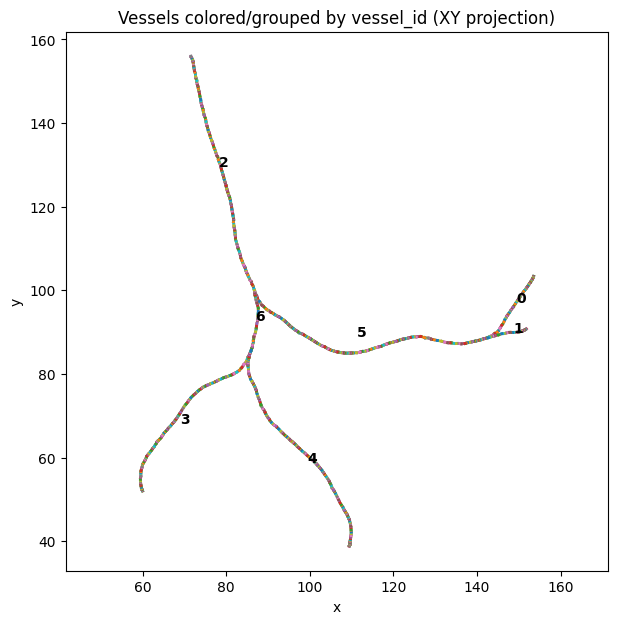

Edges missing vessel_id: 0


In [ ]:
#@title Plot vessels and IDs


import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

def plot_vessels_xy(G, figsize=(7,7)):
    pos = nx.get_node_attributes(G, "pos")

    # group edges by vessel_id
    groups = defaultdict(list)
    for (u,v) in G.edges():
        vid = int(G.edges[u,v].get("vessel_id", -1))
        groups[vid].append((u,v))

    plt.figure(figsize=figsize)

    # draw each vessel group
    for vid, edges in groups.items():
        for (u,v) in edges:
            x0,y0,_ = pos[u]
            x1,y1,_ = pos[v]
            plt.plot([x0,x1],[y0,y1], linewidth=2)

        # label: average of midpoints
        mids = []
        for (u,v) in edges:
            p0 = np.array(pos[u], float)
            p1 = np.array(pos[v], float)
            mids.append(0.5*(p0+p1))
        mids = np.array(mids)
        xm, ym = mids[:,0].mean(), mids[:,1].mean()
        plt.text(xm, ym, str(vid), fontsize=10, weight="bold")

    plt.axis("equal")
    plt.xlabel("x"); plt.ylabel("y")
    plt.title("Vessels colored/grouped by vessel_id (XY projection)")
    plt.show()

plot_vessels_xy(G)
print("Edges missing vessel_id:", sum(1 for e in G.edges if "vessel_id" not in G.edges[e]))



In [ ]:
#@title Indexing

# Find vessel ID of the center-bottom branch
# It should be the daughter at Bif 400 that goes downward (most negative y direction)
Lambda.init(0, 1)
v2c = Lambda.topology()(0, 1)
coords = Lambda.coordinates()

print("\n--- Bif 400 daughter branch directions ---")
bif_coord = coords[400]
for c in v2c(400):
    cell = Cell(Lambda, c)
    vids = cell.entities(0)
    # Find the vertex that is NOT the bifurcation
    other_v = vids[1] if vids[0] == 400 else vids[0]
    other_coord = coords[other_v]
    direction = other_coord - bif_coord
    mp = cell.midpoint()
    r = float(radius_map_G(Point(mp.x(), mp.y(), mp.z())))
    print(f"  Cell {c}: radius_map_G={r:.4f}, "
          f"direction from bif=({direction[0]:.2f}, {direction[1]:.2f}, {direction[2]:.2f})")

print("\n--- All vessel IDs in graph ---")
vessel_id_counts = {}
for u, v_node, data in G.edges(data=True):
    vid = data.get('vessel_id', 'NONE')
    vessel_id_counts[vid] = vessel_id_counts.get(vid, 0) + 1

for vid, count in sorted(vessel_id_counts.items()):
    print(f"  vessel_id={vid}: {count} edges")

# Then check which vessel_id is near Bif 400's downward daughter
print("\n--- Vessel IDs near Bif 400 daughters ---")
bif_coord = coords[400]
for u, v_node, data in G.edges(data=True):
    u_coord = np.array(G.nodes[u]['pos'])
    v_coord = np.array(G.nodes[v_node]['pos'])
    mid = 0.5*(u_coord + v_coord)
    if np.linalg.norm(mid - bif_coord) < 2.0:
        vid = data.get('vessel_id', 'NONE')
        direction = v_coord - u_coord
        print(f"  Edge ({u},{v_node}): vessel_id={vid}, "
              f"direction=({direction[0]:.2f},{direction[1]:.2f}), "
              f"midpoint=({mid[0]:.1f},{mid[1]:.1f})")



--- Bif 400 daughter branch directions ---
  Cell 801: radius_map_G=0.0800, direction from bif=(0.04, -0.07, -0.01)
  Cell 802: radius_map_G=0.0800, direction from bif=(0.00, -0.00, -0.00)
  Cell 804: radius_map_G=0.1200, direction from bif=(-0.02, 0.06, -0.01)

--- All vessel IDs in graph ---
  vessel_id=0: 102 edges
  vessel_id=1: 59 edges
  vessel_id=2: 281 edges
  vessel_id=3: 234 edges
  vessel_id=4: 309 edges
  vessel_id=5: 298 edges
  vessel_id=6: 48 edges

--- Vessel IDs near Bif 400 daughters ---
  Edge (395,394): vessel_id=5, direction=(0.14,-0.55), midpoint=(87.4,98.4)
  Edge (396,395): vessel_id=5, direction=(0.15,-0.24), midpoint=(87.3,98.8)
  Edge (397,396): vessel_id=5, direction=(0.14,-0.22), midpoint=(87.1,99.0)
  Edge (398,397): vessel_id=5, direction=(0.07,-0.25), midpoint=(87.0,99.3)
  Edge (399,398): vessel_id=5, direction=(0.14,-0.47), midpoint=(86.9,99.6)
  Edge (400,399): vessel_id=5, direction=(0.08,-0.14), midpoint=(86.8,99.9)
  Edge (400,1022): vessel_id=6, 

In [ ]:
#@title branch specific kappa

# drop in right below # === Bifurcations ===
# === Branch specific kappa ===
  branch_cells = MeshFunction("size_t", Lambda, Lambda.topology().dim(), 0)
  bif_vtx = int(bif_vertices[0])
  incident = list(map(int, v2e(bif_vtx)))

  # classify incident cells at junction
  up_cells = []
  down_cells = []
  for c in incident:
      ov = other_vertex_of_cell_at_vtx(c, bif_vtx)
      dov = dist1d.get(ov, None)
      if dov is None:
          continue
      if dov < dv:
          up_cells.append(c)
      elif dov > dv:
          down_cells.append(c)

  if len(up_cells) != 1 or len(down_cells) < 1:
      print("WARNING: unexpected junction classification",
            "up_cells=", up_cells, "down_cells=", down_cells)
  # tag parent branch (upstream from junction)
  parent_branch_cells = walk_branch_cells_from_junction(Lambda, up_cells[0], bif_vtx)

  # tag daughter branches (downstream from junction)
  daughter_branches = [walk_branch_cells_from_junction(Lambda, c, bif_vtx) for c in down_cells]

  # assign markers: 1=parent, 2=daughterA, 3=daughterB (deterministic order)
  for c in parent_branch_cells:
      branch_cells[c] = 1
  for j, br in enumerate(sorted(daughter_branches, key=len, reverse=True), start=2):
      for c in br:
          branch_cells[c] = j

  # define branch kappas
  kappa_p  = Constant(0.1)
  kappa_d1 = Constant(0.1)
  kappa_d2 = Constant(0.0001)


  class KappaBranch(UserExpression):
      def __init__(self, markers, **kwargs):
          self.markers = markers
          super().__init__(**kwargs)
      def eval_cell(self, values, x, cell):
          tag = int(self.markers[cell.index])
          if tag == 1:
              values[0] = float(kappa_p)
          elif tag == 2:
              values[0] = float(kappa_d1)
          elif tag == 3:
              values[0] = float(kappa_d2)
          else:
              values[0] = float(kappa_p)
      def value_shape(self):
          return ()

  #kappa = KappaBranch(branch_cells, degree=0)



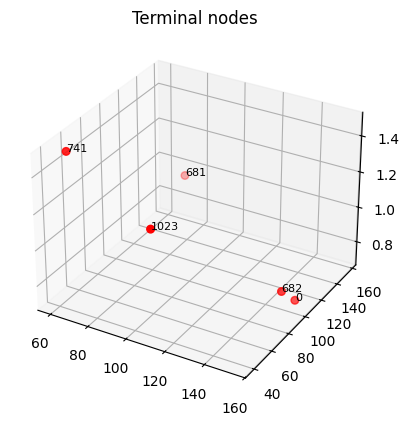

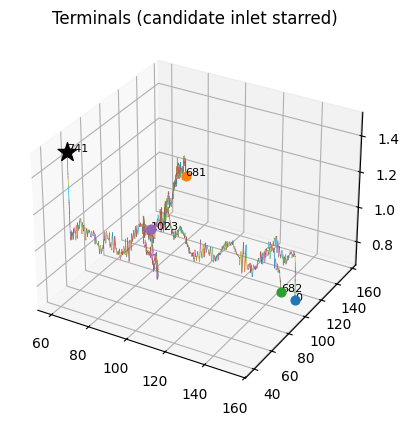

In [ ]:
#@title Find inlet vessel

import matplotlib.pyplot as plt

pos = nx.get_node_attributes(G, "pos")
xs = [pos[n][0] for n in terminals]
ys = [pos[n][1] for n in terminals]
zs = [pos[n][2] for n in terminals]

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(xs, ys, zs, c="r", s=30)

for n in terminals:
    ax.text(*pos[n], str(n), fontsize=8)

ax.set_title("Terminal nodes")
plt.show()

pos = nx.get_node_attributes(G,"pos")
terminals = [n for n in G.nodes if G.degree[n]==1]

cand = 741  # your candidate inlet

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# plot edges as thin lines
for u,v in G.edges():
    pu, pv = np.array(pos[u]), np.array(pos[v])
    ax.plot([pu[0], pv[0]], [pu[1], pv[1]], [pu[2], pv[2]], linewidth=0.5)

# terminals
for n in terminals:
    p = pos[n]
    ax.scatter(p[0], p[1], p[2], s=40)
    ax.text(p[0], p[1], p[2], str(n), fontsize=8)

# candidate inlet emphasized
p = pos[cand]
ax.scatter(p[0], p[1], p[2], s=200, marker="*", c="k")
ax.set_title("Terminals (candidate inlet starred)")
plt.show()

In [ ]:
#@title Define functions (Y bifurcation-specific)
from math import gamma
from argparse import RawDescriptionHelpFormatter
from petsc4py import PETSc
from dolfin import *
from xii import *
import numpy as np
import time
import networkx as nx
from graphnics import FenicsGraph
from scipy.spatial import cKDTree
from itertools import combinations
from collections import deque

def bif_tangents(G):
    pos   = nx.get_node_attributes(G,"pos")
    nodes = list(G.nodes)
    T     = np.zeros((len(nodes),3))
    for k, n in enumerate(nodes):
        p0 = np.array(pos[n])
        neighbor = list(G.neighbors(n))
        vec = np.zeros(3)
        for m in neighbor:
            vec += np.array(pos[m]) - p0

        norm = np.linalg.norm(vec)
        if norm > 0:
          T[k,:] = vec/norm
        else:
          T[k,:] = np.array([0,0,1.0]) #use unit normal if needed
    P = np.array([pos[n] for n in nodes])
    return nodes, P, T

class TangentExpression(UserExpression):
    def __init__(self, nodes, P, T_array, **kwargs):
        self.nodes  = nodes
        self.P      = np.asarray(P)
        self.T_array = np.asarray(T_array)
        self.kdtree = cKDTree(self.P)
        super().__init__(**kwargs)
    def eval(self,values,x):
      _, idx = self.kdtree.query((x[0],x[1],x[2]))
      tx, ty, tz = self.T_array[idx]
      values[0] = tx
      values[1] = ty
      values[2] = tz
    def value_shape(self):
      return (3,)

def make_Y_bifurcation(
    parent_len=0.45, parent_pts=4,          # parent vessel
    daughter_len=0.45, daughter_pts=4,      # identical daughter vessels
    angle_deg=35.0,                         # opening half-angle of the Y (each daughter)
    r_parent=0.05,
    r_daughter1=0.040,
    r_daughter2=0.020,
    damage_default=0.0,                     # damage field included in vtk file from Pierce's example, just made zero
    origin=(0.0, 0.0, -0.45),               # parent begins at z = -0.45
    bifurcation_z= 0.0                      # split occors at origin
):
    G = FenicsGraph()

    # === Parent: from (0,0,-0.45) to (0,0,bifurcation_z) ===
    z0 = origin[2]
    parent_zs = np.linspace(z0, bifurcation_z, parent_pts)
    parent_ids = []
    for z in parent_zs:
        i = len(G)  # next node id
        G.add_node(i, pos=(origin[0], origin[1], z), radius=r_parent, damage=damage_default)
        parent_ids.append(i)

    # Use the last parent node as the bifurcation node:
    bif_id = parent_ids[-1]
    bif_pt = G.nodes[bif_id]["pos"]

    # Connect parent and daughter paths
    for a, b in zip(parent_ids[:-1], parent_ids[1:]):
        G.add_edge(a, b)

    # === Daughters: symmetric about the z-axis in x–z plane ===
    angle = np.deg2rad(angle_deg)
    # Unit directions for the two daughters (right and left in +x/-x):
    d1 = np.array([ np.sin(angle), 0.0, np.cos(angle)])
    d2 = np.array([-np.sin(angle), 0.0, np.cos(angle)])

    def add_branch(bif_id, dir_vec, r_daughter):
        # start at the bifurcation point (re-use the node id at the bifurcation)
        # then create additional points along the ray
        ids = [bif_id]
        for k in range(1, daughter_pts):
            p = np.array(bif_pt) + (k / (daughter_pts - 1)) * daughter_len * dir_vec
            i = len(G)
            G.add_node(i, pos=tuple(p), radius=r_daughter, damage=damage_default)
            ids.append(i)
        # connect the line
        for a, b in zip(ids[:-1], ids[1:]):
            G.add_edge(a, b)

    add_branch(bif_id, d1, r_daughter1)
    add_branch(bif_id, d2, r_daughter2)

    return G

def build_bifurcation_pairs(G):
    """
    For every bifurcation node (degree > 2), return ordered pairs:
      (parent, daughter) for each daughter, and (daughter_i, daughter_j) for all daughter pairs.

    """
    pos = nx.get_node_attributes(G, 'pos')
    bif_nodes = [n for n in G.nodes if G.degree[n] > 2]
    results = []

    for b in bif_nodes:
        neighbor = list(G.neighbors(b))
        # Sort neighbors by z so smallest-z branch is treated as "parent" (upstream)
        neighbor_sorted = sorted(neighbor, key=lambda n: pos[n][2])
        parent_vessel   = neighbor_sorted[0]
        daughter_vessel = neighbor_sorted[1:]


        # Assign local vessel IDs per neighbor by walking to next junction/terminal
        vessel_id = {}
        for k, n in enumerate(neighbor_sorted, start = 1):
            vessel_id[n] = k

        parent_id = vessel_id[parent_vessel]
        daughter_id = [vessel_id[n] for n in daughter_vessel]

        results.append({
            "bif_node": b,
            "parent_id": parent_id,
            "daughter_id": daughter_id,
            "pairs": [(parent_id,d) for d in daughter_id] + list(combinations(daughter_id, 2)),
            "pos": np.array(pos[b]),
            "neighbor_sorted": neighbor_sorted,
            "vessel_id": vessel_id
        })

    return results

def bifurcation_vertices_from_graph(Lambda, bif_info):
    """Return mesh vertex indices of bifurcation points (nearest vertex to each bif node position)."""
    coords = Lambda.coordinates()

    def nearest_vertex(point):
        diff = coords - point
        return int(np.argmin(np.linalg.norm(diff, axis=1)))

    bif_vertices = []
    for bif in bif_info:
        vtx = nearest_vertex(bif["pos"])
        bif_vertices.append(vtx)
    return sorted(set(bif_vertices))


def add_kirchhoff_junction_terms_P1DG(
    A_petsc, V3, V1, Lambda, bif_vertices, D_area_expr,
    eta_gamma=10.0, epsilon=1.0
):
    """
    Assemble Kirchhoff/SIPG junction terms by writing directly into the PETSc Mat.

    """
    dm = V1.dofmap()
    coords = Lambda.coordinates()

    Lambda.init(0, 1)
    v2c = Lambda.topology()(0, 1)

    N = A_petsc.mat().getSize()[0]
    off1 = N - V1.dim()   # assumes V1 block is last in ii_convert ordering

    # get petsc4py Mat
    M = A_petsc.mat()

    M.setOption(PETSc.Mat.Option.NEW_NONZERO_ALLOCATION_ERR, False)
    M.setOption(PETSc.Mat.Option.NEW_NONZERO_LOCATION_ERR, False)

    def add_entry(I, J, val):
        # addv=True means accumulate into existing entry
        M.setValue(I, J, val, addv=True)

    for vtx in bif_vertices:
        incident_cells = list(v2c(vtx))
        m = len(incident_cells)
        if m < 3:
            continue

        branches = []
        h_gamma = 0.0

        for c in incident_cells:
            cell = Cell(Lambda, c)
            vids = cell.entities(0)
            x0 = coords[vids[0]]
            x1 = coords[vids[1]]
            hK = float(np.linalg.norm(x1 - x0))
            h_gamma = max(h_gamma, hK)

            if vids[0] == vtx:
                loc_g, loc_o = 0, 1
                x_mid = 0.5*(x0 + x1)
            else:
                loc_g, loc_o = 1, 0
                x_mid = 0.5*(x0 + x1)

            cdofs = dm.cell_dofs(c)  # DG1: 2 dofs per cell
            dof_g = int(cdofs[loc_g])
            dof_o = int(cdofs[loc_o])

            Da = float(D_area_expr(Point(*x_mid)))
            branches.append(dict(hK=hK, Da=Da, dof_g=dof_g, dof_o=dof_o))

        for a in range(m):
            for b in range(a + 1, m):
                Ia = branches[a]
                Ib = branches[b]

                ha, Da = Ia["hK"], Ia["Da"]
                hb, Db = Ib["hK"], Ib["Da"]
                ga, oa = Ia["dof_g"], Ia["dof_o"]
                gb, ob = Ib["dof_g"], Ib["dof_o"]

                # GLOBAL indices
                Gga, Goa = off1 + ga, off1 + oa
                Ggb, Gob = off1 + gb, off1 + ob

                # === penalty ===
                pen = eta_gamma / h_gamma
                for (I, sI) in [(Gga, +1.0), (Ggb, -1.0)]:
                    for (J, sJ) in [(Gga, +1.0), (Ggb, -1.0)]:
                        add_entry(I, J, pen * sI * sJ)

                # === New jump: -(1/m) {sigma(u)}^{ab} (v_ga - v_gb) ===
                w = -1.0 / m
                for (Row, srow) in [(Gga, +1.0), (Ggb, -1.0)]:
                    # flux_a(u) = Da*(u_oa - u_ga)/ha
                    add_entry(Row, Goa, w * srow * ( Da/ha))
                    add_entry(Row, Gga, w * srow * (-Da/ha))
                    # -flux_b(u) = -Db*(u_ob - u_gb)/hb
                    add_entry(Row, Gob, w * srow * (-Db/hb))
                    add_entry(Row, Ggb, w * srow * ( Db/hb))

                # === New average: -(eta/m) {sigma(v)}^{ab} (u_ga - u_gb) ===
                ws = -epsilon / m
                for (Col, scol) in [(Gga, +1.0), (Ggb, -1.0)]:
                    # flux_a(v) rows
                    add_entry(Goa, Col, ws * scol * ( Da/ha))
                    add_entry(Gga, Col, ws * scol * (-Da/ha))
                    # -flux_b(v) rows
                    add_entry(Gob, Col, ws * scol * (-Db/hb))
                    add_entry(Ggb, Col, ws * scol * ( Db/hb))

    # finalize PETSc assembly
    M.assemblyBegin()
    M.assemblyEnd()

def advection_junction_terms_P1DG(
    A_petsc, V3, V1, Lambda, bif_vertices, D_area_expr,
    q1_value=1.0
):
    dm = V1.dofmap()
    coords = Lambda.coordinates()

    Lambda.init(0, 1)
    v2c = Lambda.topology()(0, 1)

    # Use the same safe offset as for diffusion:
    N = A_petsc.mat().getSize()[0]
    off1 = N - V1.dim()   # V1 block last

    M = A_petsc.mat()
    M.setOption(PETSc.Mat.Option.NEW_NONZERO_ALLOCATION_ERR, False)
    M.setOption(PETSc.Mat.Option.NEW_NONZERO_LOCATION_ERR, False)

    def add_entry(I, J, val):
        M.setValue(I, J, float(val), addv=True)

    for vtx in bif_vertices:
        cells = list(v2c(vtx))
        if len(cells) != 3:
            continue  # expecting a Y junction

        xg = coords[vtx]
        branches = []

        # 1) collect branch data
        for c in cells:
            cell = Cell(Lambda, c)
            vids = cell.entities(0)
            x0, x1 = coords[vids[0]], coords[vids[1]]

            if vids[0] == vtx:
                loc_g = 0
                other = x1
                x_mid = 0.5*(x0 + x1)
            else:
                loc_g = 1
                other = x0
                x_mid = 0.5*(x0 + x1)

            dof_g = int(dm.cell_dofs(c)[loc_g])
            A_here = float(D_area_expr(Point(*x_mid)))
            Q_here = A_here * float(q1_value)

            branches.append({
                "dof_g": dof_g,
                "Q": Q_here,
                "z_other": other[2],
            })

        # 2) classify: inflow = smallest z_other (parent), outflows = other two
        inflow = min(branches, key=lambda b: b["z_other"])
        outflows = [b for b in branches if b is not inflow]

        Gin = off1 + inflow["dof_g"]

        # 3) assemble: sum_out Q_out * u_in * (v_out - v_in)
        Qsum = 0.0
        for b in outflows:
            Gout = off1 + b["dof_g"]
            Q = b["Q"]
            Qsum += Q
            add_entry(Gout, Gin, +Q)   # v_out * u_in
        add_entry(Gin, Gin, -Qsum)     # -v_in * u_in

    M.assemblyBegin()
    M.assemblyEnd()


def kirchhoff_residual_at_vertex(Lambda, V1, uh1d, vtx, D_area_expr):
  coords = Lambda.coordinates()
  dm = V1.dofmap()

  Lambda.init(0, 1)
  v2c = Lambda.topology()(0, 1)
  cells = list(v2c(vtx))

  res = 0.0
  fluxes = []
  for c in cells:
      cell = Cell(Lambda, c)
      vids = cell.entities(0)
      x0 = coords[vids[0]]
      x1 = coords[vids[1]]
      hK = float(np.linalg.norm(x1 - x0))
      x_mid = 0.5*(x0 + x1)
      Da = float(D_area_expr(Point(*x_mid)))

      cdofs = dm.cell_dofs(c)
      # local dof at junction vs other endpoint
      if vids[0] == vtx:
          dof_g, dof_o = int(cdofs[0]), int(cdofs[1])
      else:
          dof_g, dof_o = int(cdofs[1]), int(cdofs[0])

      ug = uh1d.vector()[dof_g]
      uo = uh1d.vector()[dof_o]
      F = Da * (uo - ug) / hK  # outgoing flux from junction into cell
      fluxes.append(F)
      res += F

  return res, fluxes

def advection_junction_terms_P1DG_flow_based(
    A_petsc, V1, Lambda, bif_vertices, D_area_expr, t_vec, q1_value=1.0
):
    dm = V1.dofmap()
    coords = Lambda.coordinates()
    Lambda.init(0, 1)
    v2c = Lambda.topology()(0, 1)

    N = A_petsc.mat().getSize()[0]
    off1 = N - V1.dim()

    M = A_petsc.mat()
    M.setOption(PETSc.Mat.Option.NEW_NONZERO_ALLOCATION_ERR, False)
    M.setOption(PETSc.Mat.Option.NEW_NONZERO_LOCATION_ERR, False)

    def add_entry(I, J, val):
        M.setValue(I, J, float(val), addv=True)

    for vtx in bif_vertices:
        cells = list(v2c(vtx))
        if len(cells) < 3:
            continue

        xg = coords[vtx]
        branches = []

        for c in cells:
            cell = Cell(Lambda, c)
            vids = cell.entities(0)
            x0, x1 = coords[vids[0]], coords[vids[1]]

            # vector from junction -> other endpoint (points into the branch)
            if vids[0] == vtx:
                loc_g = 0
                xother = x1
            else:
                loc_g = 1
                xother = x0

            d = xother - xg
            d_hat = d / np.linalg.norm(d)

            x_mid = 0.5*(xg + xother)
            tmid = np.array(t_vec(Point(*x_mid)))
            tmid /= np.linalg.norm(tmid)

            # signed velocity along this branch away from junction
            s = float(q1_value) * float(np.dot(tmid, d_hat))

            A = float(D_area_expr(Point(*x_mid)))
            Q = A * abs(s)

            dof_g = int(dm.cell_dofs(c)[loc_g])

            branches.append(dict(cell=c, dof_g=dof_g, s=s, Q=Q))

        inflows  = [b for b in branches if b["s"] < 0.0 and b["Q"] > 0.0]
        outflows = [b for b in branches if b["s"] > 0.0 and b["Q"] > 0.0]

        if len(outflows) == 0 or len(inflows) == 0:
            continue

        # Build node value as weighted inflow average:
        Q_in_sum = sum(b["Q"] for b in inflows)


        for bout in outflows:
            Gout = off1 + bout["dof_g"]
            Qout = bout["Q"]

            # outflow receives weighted mix of inflow dofs
            for bin_ in inflows:
                Gin = off1 + bin_["dof_g"]
                add_entry(Gout, Gin, Qout * (bin_["Q"]/Q_in_sum))

            # diagonal damping so it behaves like a node balance
            add_entry(Gout, Gout, -Qout)

    M.assemblyBegin()
    M.assemblyEnd()


def build_cell_tangent_expression(Lambda, degree=0):
    coords = Lambda.coordinates()
    cell_mids = []
    cell_tans = []

    for c in range(Lambda.num_cells()):
        cell = Cell(Lambda, c)
        vids = cell.entities(0)
        x0, x1 = coords[vids[0]], coords[vids[1]]

        t = x1 - x0
        t /= np.linalg.norm(t)

        # === ORIENT tangent consistently (toward +z) ===
        # this is specific to this network need to come back and revise for general
        if t[2] < 0.0:
            t = -t

        cell_mids.append(0.5*(x0 + x1))
        cell_tans.append(t)

    cell_mids = np.array(cell_mids)
    cell_tans = np.array(cell_tans)
    kdt = cKDTree(cell_mids)

    class CellTangent(UserExpression):
        def eval(self, values, x):
            _, idx = kdt.query((x[0], x[1], x[2]))
            values[:] = cell_tans[idx]
        def value_shape(self): return (3,)

    return CellTangent(degree=degree)

def build_bfs_tangent_expression(Lambda, inlet_v, degree=0):
    coords = Lambda.coordinates()
    conn   = Lambda.cells()  # (v0,v1) per cell

    # === BFS distances on the vertex graph ===
    adj = {v: [] for v in range(Lambda.num_vertices())}
    for a, b in conn:
        a = int(a); b = int(b)
        adj[a].append(b); adj[b].append(a)

    dist = {int(inlet_v): 0}
    q = deque([int(inlet_v)])
    while q:
        v = q.popleft()
        for nb in adj[v]:
            if nb not in dist:
                dist[nb] = dist[v] + 1
                q.append(nb)

    # === per-cell downstream tangent (from smaller dist -> larger dist) ===
    cell_mids = []
    cell_tans = []

    for c, (a, b) in enumerate(conn):
        a = int(a); b = int(b)
        da = dist.get(a, None)
        db = dist.get(b, None)
        if da is None or db is None:

            up, dn = a, b
        else:
            up, dn = (a, b) if da <= db else (b, a)

        x_up = coords[up]
        x_dn = coords[dn]
        t = x_dn - x_up
        t /= np.linalg.norm(t)

        cell_mids.append(0.5*(x_up + x_dn))
        cell_tans.append(t)

    cell_mids = np.array(cell_mids)
    cell_tans = np.array(cell_tans)
    kdt = cKDTree(cell_mids)

    class BFSTangent(UserExpression):
        def eval(self, values, x):
            _, idx = kdt.query((x[0], x[1], x[2]))
            values[:] = cell_tans[idx]
        def value_shape(self):
            return (3,)

    return BFSTangent(degree=degree)

def outlet_bn_geometric(Lambda, endpoints, Lambda_boundaries, t_vec, q1_value=1.0):
    coords = Lambda.coordinates()
    Lambda.init(0, 1)
    v2e = Lambda.topology()(0, 1)
    e2v = Lambda.topology()(1, 0)

    for v in endpoints:
        if Lambda_boundaries.array()[v] != 2:
            continue  # only outlets

        # endpoint has exactly one incident edge
        e = int(v2e(v)[0])
        vids = e2v(e)

        # other vertex on that edge
        v_other = int(vids[0] if vids[1] == v else vids[1])

        x_end   = coords[v]
        x_other = coords[v_other]

        # outward direction from interior -> endpoint
        d = x_end - x_other
        d_hat = d / np.linalg.norm(d)

        # evaluate your tangent (UserExpression) at edge midpoint
        x_mid = 0.5 * (x_end + x_other)
        tmid = np.array(t_vec(Point(*x_mid)))
        tmid = tmid / np.linalg.norm(tmid)

        bn = float(q1_value) * float(np.dot(tmid, d_hat))
        print(f"outlet vertex {v}: other={v_other}, bn≈{bn:+.6e}, tmid={tmid}, dout={d_hat}")

def branch_cells_from_outlet(Lambda, bif_vtx, outlet_vtx):
    """Return ordered list of cell indices from bif_vtx -> outlet_vtx."""
    coords = Lambda.coordinates()
    Lambda.init(0, 1)
    v2c = Lambda.topology()(0, 1)

    # In 1D, outlet vertex touches exactly 1 cell
    current_cell = int(v2c(outlet_vtx)[0])
    cells = [current_cell]

    # Walk toward the bifurcation: each interior vertex has 2 incident cells
    while True:
        cell = Cell(Lambda, current_cell)
        vids = cell.entities(0)

        # pick the vertext closest to bifurcation
        # Step by finding which vertex of this cell has degree 2 (interior) until we reach bif_vtx.
        if bif_vtx in vids:
            break  # reached bifurcation cell

        # choose the vertex that is not the endpoint and keep moving
        # Candidate next vertices are vids[0], vids[1]; one of them leads to another cell.
        next_vertex = None
        for v in vids:
            if v == outlet_vtx:
                continue
            # if this vertex is not the outlet and has 2 incident cells, it is interior
            if len(v2c(v)) == 2:
                next_vertex = v
                break

        if next_vertex is None:
            # fallback: choose vertex that is not outlet_vtx
            next_vertex = vids[0] if vids[1] == outlet_vtx else vids[1]

        # Move to the other incident cell across next_vertex
        inc = list(v2c(next_vertex))
        next_cell = inc[0] if inc[1] == current_cell else inc[1]

        current_cell = int(next_cell)
        cells.append(current_cell)

    return list(reversed(cells))  # bif -> outlet order

def rel_diff(a, b):
    return abs(a-b) / max(1e-16, 0.5*(abs(a)+abs(b)))

def classify_branch_cells(Lambda, bif_vtx):
    coords = Lambda.coordinates()
    bif_x = coords[bif_vtx]              # numpy array shape (3,)

    left = []
    right = []

    for c in range(Lambda.num_cells()):
        cell = Cell(Lambda, c)
        mpP = cell.midpoint()            # dolfin Point
        mp  = np.array(mpP.array())      # numpy array (3,)

        d = mp - bif_x                   # numpy - numpy works

        # ignore parent branch (z <= 0 relative to bif)
        if d[2] <= 0.0:
            continue

        # classify by x sign
        if mp[0] > 0.0:
            right.append((np.linalg.norm(d), c))
        else:
            left.append((np.linalg.norm(d), c))

    left.sort()
    right.sort()

    return [c for _, c in left], [c for _, c in right]

# May switch back to this function for general network
class radius_function(UserExpression):
    def __init__(self, G, node_list, kdtree, **kwargs):
        self.G = G
        self.node_list = node_list
        self.kdtree = kdtree
        super().__init__(**kwargs)
    def eval(self, value, x):
        _, idx = self.kdtree.query((x[0], x[1], x[2]))
        node = self.node_list[idx]
        value[0] = float(self.G.nodes[node]['radius'])
    def value_shape(self):
        return ()

# Currently using this function due to how mesh was created
class edge_radius_function(UserExpression):
    def __init__(self, edge_midpoints, edge_radii, kdtree, **kwargs):
        super().__init__(**kwargs)
        self.edge_midpoints = edge_midpoints
        self.edge_radii = edge_radii
        self.kdtree = kdtree

    def eval(self, value, x):
        _, idx = self.kdtree.query((x[0], x[1], x[2]))
        value[0] = float(self.edge_radii[idx])

    def value_shape(self):
        return ()

In [ ]:
#@title Checks
n = min(len(left_cells), len(right_cells))
for k in range(n):
    mpL = Cell(Lambda, left_cells[k]).midpoint()
    mpR = Cell(Lambda, right_cells[k]).midpoint()
    uL = float(uh1d(mpL))
    uR = float(uh1d(mpR))
    print(f"k={k:2d}: uL={uL:.8e}, uR={uR:.8e}, diff={uL-uR:+.2e}")

diffs = [float(uh1d(Cell(Lambda,left_cells[k]).midpoint())
              - uh1d(Cell(Lambda,right_cells[k]).midpoint()))
        for k in range(n)]

print("max |diff| =", max(abs(d) for d in diffs))

def print_branch_Qs(Lambda, bif_vertices, D_area_expr, q1_value=1.0):
    coords = Lambda.coordinates()
    Lambda.init(0, 1)
    v2c = Lambda.topology()(0, 1)

    for vtx in bif_vertices:
        cells = list(v2c(vtx))
        if len(cells) != 3:
            continue

        print(f"\nVertex {vtx} branch Qs:")
        for c in cells:
            cell = Cell(Lambda, c)
            vids = cell.entities(0)
            x0, x1 = coords[vids[0]], coords[vids[1]]
            x_mid = 0.5*(x0 + x1)
            A = float(D_area_expr(Point(*x_mid)))
            Q = A*float(q1_value)

            # identify which side is "other" endpoint
            other = x1 if vids[0] == vtx else x0
            print(f"  cell {c:3d}: other z={other[2]:+.4f},  A={A:.8e},  Q={Q:.8e}")

def print_branch_h(Lambda, bif_vertices):
    coords = Lambda.coordinates()
    Lambda.init(0, 1)
    v2c = Lambda.topology()(0, 1)

    for vtx in bif_vertices:
        cells = list(v2c(vtx))
        if len(cells) != 3:
            continue

        print(f"\nVertex {vtx} branch h:")
        for c in cells:
            cell = Cell(Lambda, c)
            vids = cell.entities(0)
            x0, x1 = coords[vids[0]], coords[vids[1]]
            h = float(np.linalg.norm(x1-x0))
            other = x1 if vids[0] == vtx else x0
            print(f"  cell {c:3d}: other z={other[2]:+.4f}, h={h:.8e}")

print_branch_Qs(Lambda, bif_vertices, D_area, q1_value=1.0)
print_branch_h(Lambda, bif_vertices)



Vertex 3 branch Qs:
  cell   5: other z=-0.0750,  A=3.92699082e-03,  Q=3.92699082e-03
  cell   6: other z=+0.0614,  A=3.92699082e-03,  Q=3.92699082e-03
  cell   8: other z=+0.0614,  A=3.92699082e-03,  Q=3.92699082e-03

Vertex 3 branch h:
  cell   5: other z=-0.0750, h=7.50000000e-02
  cell   6: other z=+0.0614, h=7.50000000e-02
  cell   8: other z=+0.0614, h=7.50000000e-02


In [ ]:
#@title Visualize exchange-active vessel segments
# Shows which cells of the 1D network have tissue exchange turned on (orange-red)
# vs off (blue). Requires: Lambda, exchange_mask_fn, d_exchange, kappa_val
# (all defined in the main solver cell above).

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import numpy as np
from dolfin import cells as fenics_cells

coords   = Lambda.coordinates()
mask_arr = exchange_mask_fn.vector().get_local()
dm_mask  = exchange_mask_fn.function_space().dofmap()

segs_off, segs_on = [], []
for cell in fenics_cells(Lambda):
    vids = cell.entities(0)
    p0, p1 = coords[vids[0]], coords[vids[1]]
    m = float(mask_arr[int(dm_mask.cell_dofs(cell.index())[0])])
    (segs_on if m > 0.5 else segs_off).append([p0, p1])

fig = plt.figure(figsize=(11, 8))
ax  = fig.add_subplot(111, projection='3d')

if segs_off:
    ax.add_collection3d(Line3DCollection(
        segs_off, colors='steelblue', linewidths=0.6, alpha=0.35,
        label=f'No exchange ({len(segs_off)} cells)'))
if segs_on:
    ax.add_collection3d(Line3DCollection(
        segs_on, colors='orangered', linewidths=2.5, alpha=1.0,
        label=f'Exchange active ({len(segs_on)} cells, within {d_exchange} mm of outlet)'))

pts = coords
ax.set_xlim(pts[:,0].min(), pts[:,0].max())
ax.set_ylim(pts[:,1].min(), pts[:,1].max())
ax.set_zlim(pts[:,2].min(), pts[:,2].max())
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)'); ax.set_zlabel('z (mm)')
ax.set_title(
    f'Exchange zone — {len(segs_on)}/{Lambda.num_cells()} cells active'
    f' ({100*len(segs_on)/Lambda.num_cells():.1f}%)\n'
    f'kappa={kappa_val}   d_exchange={d_exchange} mm',
    fontsize=11)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print(f"Exchange active : {len(segs_on):>4} / {Lambda.num_cells()} cells  "
      f"({100*len(segs_on)/Lambda.num_cells():.1f}%)")
print(f"kappa_val       : {kappa_val}")
print(f"d_exchange      : {d_exchange} mm  (increase to expand exchange zone upstream)")


In [ ]:
#@title Diffusion Masri 2025 set up

from dolfin import *
from petsc4py import PETSc
import numpy as np
import networkx as nx
from graphnics import FenicsGraph
from scipy.spatial import cKDTree

def diffusion_only_1D_with_kirchhoff(mesh_level=2, T=1.0, dt=0.1):
    G = make_Y_bifurcation()
    G.make_mesh()
    Lambda, mf_Lambda = G.get_mesh()

    coords = Lambda.coordinates()

    # === boundary markers (inlet/outlet) ===
    Lambda_boundaries = MeshFunction("size_t", Lambda, 0, 0)
    Lambda.init(0, 1)
    v2e = Lambda.topology()(0, 1)

    endpoints = [v for v in range(Lambda.num_vertices()) if v2e.size(v) == 1]
    inlet_v = min(endpoints, key=lambda v: coords[v, 2])

    Lambda_boundaries.array()[inlet_v] = 1
    for v in endpoints:
        if v != inlet_v:
            Lambda_boundaries.array()[v] = 2

    # === find bifurcation vertex ===
    bif_info = build_bifurcation_pairs(G)
    bif_vertices = bifurcation_vertices_from_graph(Lambda, bif_info)

    # === mark junction vertices for splitting dS ===
    facet_tags = MeshFunction("size_t", Lambda, 0, 0)
    for vtx in bif_vertices:
        facet_tags.array()[vtx] = 1

    # === radius/area mapping ===
    pos = nx.get_node_attributes(G, "pos")
    edge_midpoints, edge_radii = [], []
    for (a, b) in G.edges():
        pa = np.array(pos[a]); pb = np.array(pos[b])
        pmid = 0.5*(pa + pb)
        r_edge = 0.5*(float(G.nodes[a]["radius"]) + float(G.nodes[b]["radius"]))
        edge_midpoints.append(pmid); edge_radii.append(r_edge)

    edge_kdtree = cKDTree(np.array(edge_midpoints))
    radius_map_G = edge_radius_function(np.array(edge_midpoints),
                                        np.array(edge_radii),
                                        edge_kdtree, degree=0)
    D_area = pi*radius_map_G**2

    # === space ===
    V1 = FunctionSpace(Lambda, "DG", 1)
    u1 = TrialFunction(V1)
    v1 = TestFunction(V1)

    # === measures ===
    dxL = Measure("dx", domain=Lambda)
    dsL = Measure("ds", domain=Lambda, subdomain_data=Lambda_boundaries)

    dS_all = Measure("dS", domain=Lambda)
    dS_tag = Measure("dS", domain=Lambda, subdomain_data=facet_tags)
    dS_jun = dS_tag(1)
    dS_reg = dS_tag(0)

    n1d = FacetNormal(Lambda)
    h1d = CellDiameter(Lambda)

    # === parameters ===
    alpha1d = Constant(50.0)
    eps = Constant(1.0)
    inv_dt = Constant(1.0/dt)

    # === inlet pulse ===
    cinlet = Constant(5.0)
    tau = 0.1
    pulse = Constant(0.0)

    uh_prev = interpolate(Constant(0.0), V1)

    t = 0.0
    for step in range(int(T/dt)):
        t += dt
        pulse.assign(1.0 if t <= tau else 0.0)

        a11 = (
            D_area*inv_dt*u1*v1*dxL
            + D_area*inner(grad(u1), grad(v1))*dxL
            # SIPG ONLY on regular interior vertices
            - avg(D_area)*inner(avg(grad(u1)), jump(v1, n1d))*dS_reg
            - eps*avg(D_area)*inner(avg(grad(v1)), jump(u1, n1d))*dS_reg
            + (alpha1d*avg(D_area)/avg(h1d))*jump(u1)*jump(v1)*dS_reg
        )

        L1 = (
            D_area*inv_dt*uh_prev*v1*dxL
            + pulse*D_area*cinlet*v1*dsL(1)
        )

        A = assemble(a11)
        b = assemble(L1)

        A_d = as_backend_type(A)
        b_d = as_backend_type(b)

        A_p = PETScMatrix(A_d.mat())
        b_p = PETScVector(b_d.vec())

        # Kirchhoff replaces the junction diffusion coupling
        add_kirchhoff_junction_terms_P1DG(
            A_p, V1, Lambda, bif_vertices, D_area, 10.0, 1.0
            )


        A_p.apply("insert")

        x = b_p.copy()
        solver = PETScKrylovSolver("cg", "hypre_amg")
        solver.solve(A_p, x, b_p)

        uh = Function(V1)
        uh.vector()[:] = x
        uh_prev.assign(uh)

        print(f"[t={t:.2f}] u(min,max)=({uh.vector().min():.3e},{uh.vector().max():.3e})")
        print("Junction vertices:", bif_vertices)
        print("Measure(dS_jun) =", assemble(1.0*dS_jun))
        print("Measure(dS_all) =", assemble(1.0*dS_all))
        print("Measure(dS_reg) =", assemble(1.0*dS_reg))

    File("Y_1D_diffusion_kirchhoff.pvd") << uh_prev

    return Lambda, uh_prev, dS_reg, dS_jun

Lambda, uh, dS_reg, dS_jun = diffusion_only_1D_with_kirchhoff(mesh_level=2, T=1.0, dt=0.1)

[t=0.10] u(min,max)=(1.770e-01,1.572e+00)
Junction vertices: [4]
    Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:    Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:    Compiling form ffc_form_09fafb4731057c036f824a22f0431e1315ccb2d6
    
INFO:FFC:    Compiler stage 1: Analyzing form(s)
INFO:FFC:    -----------------------------------
DEBUG:FFC:      Preprocessing form using 'uflacs' representation family.
INFO:FFC:      
INFO:FFC:      Geometric dimension:                 3
      Number of interior_facet subdomains: 2
      Rank:                                0
      Arguments:                           '()'
      Number of coefficients:              0
      Coefficients:                        '[]'
      Unique elements:                     'Vector<3 x CG1(?,?)>'
      Unique sub elements:                 'Vector<3 x CG1(?,?)>, CG1(?,?)'
      
INFO:FFC:      representation:    auto --> uflacs
INFO:FFC:      quadrature_rule:   auto --> default
INFO:FFC:      quadrature_degree: auto --> 0
INFO:FFC:      quadrature_degree: 0
INFO:FFC:      
INFO:FFC:    Co

Measure(dS_jun) = 1.0
    Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:    Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:    Compiling form ffc_form_7d2ca52612fe90c70997c03ab9f4bb3ca4148f17
    
INFO:FFC:    Compiler stage 1: Analyzing form(s)
INFO:FFC:    -----------------------------------
DEBUG:FFC:      Preprocessing form using 'uflacs' representation family.
INFO:FFC:      
INFO:FFC:      Geometric dimension:                 3
      Number of interior_facet subdomains: 0
      Rank:                                0
      Arguments:                           '()'
      Number of coefficients:              0
      Coefficients:                        '[]'
      Unique elements:                     'Vector<3 x CG1(?,?)>'
      Unique sub elements:                 'Vector<3 x CG1(?,?)>, CG1(?,?)'
      
INFO:FFC:      representation:    auto --> uflacs
INFO:FFC:      quadrature_rule:   auto --> default
INFO:FFC:      quadrature_degree: auto --> 0
INFO:FFC:      quadrature_degree: 0
INFO:FFC:      
INFO:FFC:    Co

Measure(dS_all) = 22.0
    Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:    Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:    Compiling form ffc_form_f95776b4a89e0c32a01bb993aefd136ecfedc17e
    
INFO:FFC:    Compiler stage 1: Analyzing form(s)
INFO:FFC:    -----------------------------------
DEBUG:FFC:      Preprocessing form using 'uflacs' representation family.
INFO:FFC:      
INFO:FFC:      Geometric dimension:                 3
      Number of interior_facet subdomains: 1
      Rank:                                0
      Arguments:                           '()'
      Number of coefficients:              0
      Coefficients:                        '[]'
      Unique elements:                     'Vector<3 x CG1(?,?)>'
      Unique sub elements:                 'Vector<3 x CG1(?,?)>, CG1(?,?)'
      
INFO:FFC:      representation:    auto --> uflacs
INFO:FFC:      quadrature_rule:   auto --> default
INFO:FFC:      quadrature_degree: auto --> 0
INFO:FFC:      quadrature_degree: 0
INFO:FFC:      
INFO:FFC:    Co

Measure(dS_reg) = 21.0
[t=0.20] u(min,max)=(3.417e-01,7.974e-01)
Junction vertices: [4]
Measure(dS_jun) = 1.0
Measure(dS_all) = 22.0
Measure(dS_reg) = 21.0
[t=0.30] u(min,max)=(4.387e-01,6.303e-01)
Junction vertices: [4]
Measure(dS_jun) = 1.0
Measure(dS_all) = 22.0
Measure(dS_reg) = 21.0
[t=0.40] u(min,max)=(4.865e-01,5.692e-01)
Junction vertices: [4]
Measure(dS_jun) = 1.0
Measure(dS_all) = 22.0
Measure(dS_reg) = 21.0
[t=0.50] u(min,max)=(5.084e-01,5.441e-01)
Junction vertices: [4]
Measure(dS_jun) = 1.0
Measure(dS_all) = 22.0
Measure(dS_reg) = 21.0
[t=0.60] u(min,max)=(5.181e-01,5.335e-01)
Junction vertices: [4]
Measure(dS_jun) = 1.0
Measure(dS_all) = 22.0
Measure(dS_reg) = 21.0
[t=0.70] u(min,max)=(5.223e-01,5.290e-01)
Junction vertices: [4]
Measure(dS_jun) = 1.0
Measure(dS_all) = 22.0
Measure(dS_reg) = 21.0
[t=0.80] u(min,max)=(5.241e-01,5.270e-01)
Junction vertices: [4]
Measure(dS_jun) = 1.0
Measure(dS_all) = 22.0
Measure(dS_reg) = 21.0
[t=0.90] u(min,max)=(5.249e-01,5.262e-01)
Junc